## Common Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, gzip
import glob
import math

from pandas import read_csv

Constants & Helpers

In [3]:
FIGURE_SAVE_PATH: str = "./figures"
TABLE_SAVE_PATH: str = "./table_results"
DATASET_PATH: str = "./datasets"
DATASET_SAMPLE_NAME = "reproducible_dataset"
FILES:list[str] = ["dblp-ref-0.json", "dblp-ref-1.json", "dblp-ref-2.json", "dblp-ref-3.json"]

# Sampling length our dataset is too big this makes it more manageable to work with
# 2000 per year is a good representation of our dataset
DEV_MODE:bool = False
SAMPLES_PER_YEAR:int = 250 if DEV_MODE else 2000
# For Reproducibility
SAMPLE_SEED = 42

# Helper function to split sampled dataset into chunks to not exceed githubs 100mb file limit
def load_split_dataframe(base_path, base_name):
    pattern = os.path.join(base_path, f"{base_name}_part*.pkl")
    files = sorted(glob.glob(pattern))  # sorted ensures correct row order

    if not files:
        raise FileNotFoundError(f"No files matching {pattern}")

    parts = [pd.read_pickle(f) for f in files]
    df = pd.concat(parts, axis=0)

    return df

def save_split_dataframe(df, base_path, base_name, n_parts=4):
    n = len(df)
    part_size = math.ceil(n / n_parts)

    os.makedirs(base_path, exist_ok=True)

    for i in range(n_parts):
        start = i * part_size
        end = min((i + 1) * part_size, n)
        part = df.iloc[start:end]  # preserves index + column order

        filename = os.path.join(base_path, f"{base_name}_part{i:02d}.pkl")
        part.to_pickle(filename)
        print(f"Saved rows [{start}:{end}) to {filename}")


# DO NOT RUN Load the Sampled Datasets Below

This is the preprocessing task it only needs to be done once

### Load Dataset

In [4]:
# loading data
def read_json_lines(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

def load_all(files=FILES):
    rows = []
    for fp in files:
        for rec in read_json_lines(f"./datasets/{fp}"):
            rows.append(rec)
    return pd.DataFrame(rows)

df = load_all()

as_type = {
    "year": "category",
    "n_citation": np.uint32,
}

df = df.astype(as_type)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3079007 entries, 0 to 3079006
Data columns (total 8 columns):
 #   Column      Dtype   
---  ------      -----   
 0   abstract    object  
 1   authors     object  
 2   n_citation  uint32  
 3   references  object  
 4   title       object  
 5   venue       object  
 6   year        category
 7   id          object  
dtypes: category(1), object(6), uint32(1)
memory usage: 155.6+ MB


## Task 1: Preprocessing & Feature Generation

#### Preprocess & Sample The Dataset

In [5]:
# Drop Missing years and titles
df = df[(df["title"].notna()) & (df["year"].notna())]

# Filter out rare venues
venue_counts = df["venue"].value_counts()
df = df[df["venue"].isin(venue_counts[venue_counts >= 50].index)]

# Filter out missing venues
print(f"Removing {len(df[df['venue'].str.strip() == ""])} papers with missing venues")
df = df[df['venue'].str.strip() != ""]

# as we saw later when doing simple EDA the papers with n_citation = 50 are likely a data scraping error as it shift the distribution outside a power like distribution
# SEE:
# https://link.springer.com/article/10.1007/s100510050359
df_clean_source = df[df['n_citation'] != 50]

print(f"Sampling {SAMPLES_PER_YEAR} papers per year...")


sampled_df = (
    df_clean_source.groupby('year', observed = True)
    .apply(lambda x : x.sample(
        min(len(x), SAMPLES_PER_YEAR),
        random_state = SAMPLE_SEED
    ), include_groups = False)
    .reset_index(level = 'year')
)

# Handle normalizing or fixing the dataset on the sample since it will be less
# computationally expensive

# Replace missing abstracts with empty string
sampled_df["abstract"] = sampled_df["abstract"].fillna("")

# Combine title and abstract as one feature
sampled_df['text'] = sampled_df['title'] + " " + sampled_df['abstract']

# Normalize Text
sampled_df["title"] = sampled_df["title"].str.lower()
sampled_df["abstract"] = sampled_df["abstract"].str.lower()

# Reset Index so df rows align with matrix rows (0 to N)
sampled_df = sampled_df.reset_index(drop = True)

print(f"Original Shape: {df.shape}")
print(f"Sampled Shape: {sampled_df.shape}")
sampled_df.head()


Removing 506699 papers with missing venues
Sampling 2000 papers per year...
Original Shape: (2556505, 8)
Sampled Shape: (91812, 9)


,year,abstract,authors,n_citation,references,title,venue,id,text
0,1936,,[W. V. Quine],19,NaN,toward a calculus of concepts,Journal of Symbolic Logic,566fc941-6ba6-41ab-b579-ad3d7fe4ca27,Toward a calculus of concepts
1,1936,,[Frederic B. Fitch],24,[],a system of formal logic without an analogue t...,Journal of Symbolic Logic,62c68236-b9e5-44dd-b299-e0d03c3e7bf4,A System of Formal Logic without an Analogue t...
2,1936,,[Emil L. Post],367,[],finite combinatory processes--formulation 1,Journal of Symbolic Logic,e254cbb5-e369-49dc-97a2-4d60eaea27dd,Finite Combinatory Processes--Formulation 1
3,1936,,[J. Barkley Rosser],1,NaN,constructibility as a criterion for existence,Journal of Symbolic Logic,8581f824-2333-4b5f-b277-a4020281a7f8,Constructibility as a Criterion for Existence
4,1936,,[Alonzo Church],150,[c45bdb20-3d36-4d7d-8a83-203e3d3bff9e],correction to a note on the entscheidungsproblem,Journal of Symbolic Logic,c5c32b04-0a67-4cd6-b135-3f65ab87e33b,Correction to a Note on the Entscheidungsproblem


### Generate Black Box Features
These are for our clustering and classification tasks in our proposal.

#### TF-IDF Pipeline

In [10]:
# Run TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# In task 2 (topic clustering) german papers kept prevalent as a separate cluster
# Instead of clustering-and-dropping, we just drop rows containing common German stop words.
# This is instant and stops them from popping up again.
german_indicators = [
    " der ", " die ", " und ", " von ", " für ", " mit ",
    " ist ", " des ", " ein ", " eine ", " ich ",
    " vom ", " doch ", " sowie ", " zur ", " zum "
]
mask_german = sampled_df['text'].str.contains('|'.join(german_indicators), case=False, regex=True)
print(f"Removing {mask_german.sum()} German papers via keyword filter...")
sampled_df = sampled_df[~mask_german].reset_index(drop=True)


# Also with just the basic stop words it forms huge clusters with 40,000+ papers this is in an attempt to break this up
my_stop_words = list(TfidfVectorizer(stop_words="english").get_stop_words())

my_stop_words += [
    'based', 'using', 'method', 'paper', 'results', 'problem', 'time',
    'approach', 'new', 'proposed', 'algorithm', 'study', 'analysis',
    'data', 'use', 'number', 'systems', 'system', 'model', 'models',
    'design', 'research', 'development'
]

print("Vectorizing....")
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=my_stop_words,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(sampled_df["text"])

Removing 0 German papers via keyword filter...
Vectorizing....


#Important: You only really need to run this once after that its meaningless

We test here to find the optimal n_dimension by trying to maximize the silhoutte score for sparse text datasets its usually advised for the n_dimension to be around 50-350



=== Testing 50 components ===
Cumulative explained variance: 0.0934
Silhouette score: 0.0539

=== Testing 75 components ===
Cumulative explained variance: 0.1227
Silhouette score: 0.0458

=== Testing 100 components ===
Cumulative explained variance: 0.1483
Silhouette score: 0.0494

=== Testing 150 components ===
Cumulative explained variance: 0.1930
Silhouette score: 0.0394

=== Testing 200 components ===
Cumulative explained variance: 0.2315
Silhouette score: 0.0197

=== Testing 250 components ===
Cumulative explained variance: 0.2654
Silhouette score: 0.0257

=== Testing 300 components ===
Cumulative explained variance: 0.2957
Silhouette score: 0.0306

=== Testing 350 components ===
Cumulative explained variance: 0.3235
Silhouette score: 0.0150


,n_components,cum_explained_var,silhouette
0,50,0.093403,0.053905
1,75,0.122708,0.045783
2,100,0.148299,0.049421
3,150,0.193046,0.039359
4,200,0.231482,0.019693
5,250,0.265358,0.025674
6,300,0.295725,0.030606
7,350,0.323537,0.014976


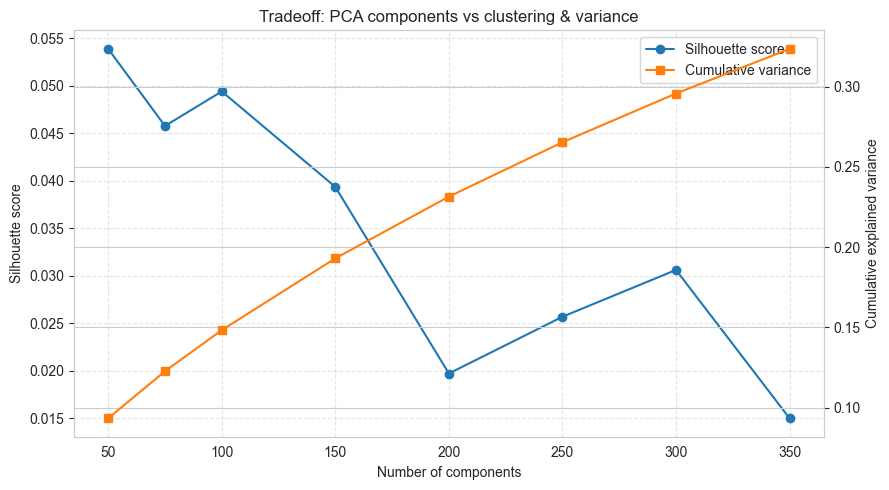

In [37]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import matplotlib.pyplot as plt


components_to_test =  [50, 75, 100, 150, 200, 250, 300, 350]
n_clusters = 9
max_sil_samples = 5000   # subsample for silhouette to keep it fast

results = []

for n_comp in components_to_test:
    print(f"\n=== Testing {n_comp} components ===")

    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    X_red = svd.fit_transform(X_tfidf)

    cum_var = svd.explained_variance_ratio_.sum()
    print(f"Cumulative explained variance: {cum_var:.4f}")

    # K-means on reduced data
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = km.fit_predict(X_red)

    # Subsample for silhouette (it’s O(n^2))
    if X_red.shape[0] > max_sil_samples:
        idx = np.random.choice(X_red.shape[0], max_sil_samples, replace=False)
        sil = silhouette_score(X_red[idx], labels[idx])
    else:
        sil = silhouette_score(X_red, labels)

    print(f"Silhouette score: {sil:.4f}")

    results.append({
        "n_components": n_comp,
        "cum_explained_var": cum_var,
        "silhouette": sil
    })

results_df = pd.DataFrame(results)
display(results_df)

# plot the tradeoff
fig, ax1 = plt.subplots(figsize=(9,5))

ax1.plot(results_df["n_components"], results_df["silhouette"],
         marker="o", label="Silhouette score")
ax1.set_xlabel("Number of components")
ax1.set_ylabel("Silhouette score")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(results_df["n_components"], results_df["cum_explained_var"],
         marker="s", color="tab:orange", label="Cumulative variance")
ax2.set_ylabel("Cumulative explained variance")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")

plt.title("Tradeoff: PCA components vs clustering & variance")
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/pca_ncomponent_tradeoff.png")
plt.show()


#### PCA Preprocess Pipeline

In [14]:
# PCA Feature Pipeline
from sklearn.decomposition import PCA

# Check if PCA columns already exist and drop them so we don't get duplicates
cols_to_drop = [c for c in sampled_df.columns if c.startswith('pca_') or c == 'cluster']
sampled_df = sampled_df.drop(columns=cols_to_drop, errors='ignore')

# Run PCA
OPTIMAL_N_COMPONENT = 50
# See above plot to find the optimal n_components
pca = PCA(n_components=OPTIMAL_N_COMPONENT, random_state=SAMPLE_SEED)
X_pca = pca.fit_transform(X_tfidf.toarray())

# Create a df from PCA results and attach it to sampled_df
pca_cols = [f"pca_{i}" for i in range(OPTIMAL_N_COMPONENT)]
pca_df = pd.DataFrame(X_pca, columns=pca_cols)
sampled_df = pd.concat([sampled_df, pca_df], axis=1)

# Author and Venue Embeddings
# Venue embeddings
venue_emb = sampled_df.groupby("venue")[pca_cols].mean()

# Author embeddings
authors_exploded = []
authors_emb = []
authors_exploded = sampled_df.explode('authors')
author_emb = authors_exploded.groupby('authors')[pca_cols].mean()

#### Generate Interpretable Features
These are the metadata features for trend analysis and network analysis

In [15]:
# Number of Authors (Collaboration Size)
sampled_df['num_authors'] = sampled_df['authors'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Title Length (Character Count)
sampled_df['title_length'] = sampled_df['title'].apply(lambda x: len(str(x)))

# Number of References (How many papers this paper cites)
sampled_df['num_refs'] = sampled_df['references'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Citation Velocity (Citations per year)
sampled_df['citation_velocity'] = sampled_df['n_citation'] / (2018 - sampled_df['year'].astype(int) + 1)
print(sampled_df['citation_velocity'].max())

# Change the types as well to reduce memory
as_type = {
    "num_authors": "category",
    "title_length": np.uint16,
    "num_refs": np.uint8,
    "citation_velocity": np.float32,
}

sampled_df[["title", 'year', 'num_authors', 'num_refs', 'citation_velocity']].head()

1662.4


,title,year,num_authors,num_refs,citation_velocity
0,toward a calculus of concepts,1936,1,0,0.228916
1,a system of formal logic without an analogue t...,1936,1,0,0.289157
2,finite combinatory processes--formulation 1,1936,1,0,4.421687
3,constructibility as a criterion for existence,1936,1,0,0.012048
4,correction to a note on the entscheidungsproblem,1936,1,1,1.807229


# Saved Sample Dataset

For reproducibility and to reduce overhead of loading the dataset save it

In [84]:
save_split_dataframe(sampled_df, DATASET_PATH, DATASET_SAMPLE_NAME, 10)

Saved rows [0:9020) to ./datasets\reproducible_dataset_part00.pkl
Saved rows [9020:18040) to ./datasets\reproducible_dataset_part01.pkl
Saved rows [18040:27060) to ./datasets\reproducible_dataset_part02.pkl
Saved rows [27060:36080) to ./datasets\reproducible_dataset_part03.pkl
Saved rows [36080:45100) to ./datasets\reproducible_dataset_part04.pkl
Saved rows [45100:54120) to ./datasets\reproducible_dataset_part05.pkl
Saved rows [54120:63140) to ./datasets\reproducible_dataset_part06.pkl
Saved rows [63140:72160) to ./datasets\reproducible_dataset_part07.pkl
Saved rows [72160:81180) to ./datasets\reproducible_dataset_part08.pkl
Saved rows [81180:90191) to ./datasets\reproducible_dataset_part09.pkl


Load saved sampled dataset

In [4]:
sampled_df = load_split_dataframe(DATASET_PATH, DATASET_SAMPLE_NAME)
classification_df = load_split_dataframe(DATASET_PATH, "classification_df")
sampled_df.head(10)

,year,abstract,authors,n_citation,references,title,venue,id,text,num_authors,...,pca_47,pca_48,pca_49,cluster,label,tsne_x,tsne_y,blob_k14,topic_label,super_topic
0,1936-01-01,,[W. V. Quine],19,NaN,toward a calculus of concepts,Journal of Symbolic Logic,566fc941-6ba6-41ab-b579-ad3d7fe4ca27,Toward a calculus of concepts,1,...,0.017808,0.008910,-0.010326,12,General CS & Applications,26.144827,29.181383,0.0,Logic/Proof & Semantics Core,Theory & Algorithms
1,1936-01-01,,[Frederic B. Fitch],24,[],a system of formal logic without an analogue t...,Journal of Symbolic Logic,62c68236-b9e5-44dd-b299-e0d03c3e7bf4,A System of Formal Logic without an Analogue t...,1,...,0.006718,-0.022645,-0.019774,7,Logic Programming,29.045454,93.968498,NaN,Logic Programming,Theory & Algorithms
2,1936-01-01,,[Emil L. Post],367,[],finite combinatory processes--formulation 1,Journal of Symbolic Logic,e254cbb5-e369-49dc-97a2-4d60eaea27dd,Finite Combinatory Processes--Formulation 1,1,...,-0.048536,0.038909,0.053052,0,Algorithms & Optimization,53.042477,30.663332,NaN,Algorithms & Optimization,Theory & Algorithms
3,1936-01-01,,[J. Barkley Rosser],1,NaN,constructibility as a criterion for existence,Journal of Symbolic Logic,8581f824-2333-4b5f-b277-a4020281a7f8,Constructibility as a Criterion for Existence,1,...,0.001151,0.002429,-0.010975,12,General CS & Applications,28.988430,9.766901,0.0,Logic/Proof & Semantics Core,Theory & Algorithms
4,1936-01-01,,[Alonzo Church],150,[c45bdb20-3d36-4d7d-8a83-203e3d3bff9e],correction to a note on the entscheidungsproblem,Journal of Symbolic Logic,c5c32b04-0a67-4cd6-b135-3f65ab87e33b,Correction to a Note on the Entscheidungsproblem,1,...,-0.083212,0.039810,-0.026251,12,General CS & Applications,89.279663,46.457516,0.0,Logic/Proof & Semantics Core,Theory & Algorithms
5,1936-01-01,,[Alonzo Church],949,[],a note on the entscheidungsproblem,Journal of Symbolic Logic,c45bdb20-3d36-4d7d-8a83-203e3d3bff9e,A Note on the Entscheidungsproblem,1,...,-0.105636,0.066998,-0.049147,12,General CS & Applications,90.358742,47.006649,0.0,Logic/Proof & Semantics Core,Theory & Algorithms
6,1937-01-01,,[A. M. Turing],552,[],computability and λ-definability,Journal of Symbolic Logic,0ae42956-0f17-4fd8-9453-baf2d0961c1a,Computability and λ-definability,1,...,-0.000305,-0.001626,-0.000838,12,General CS & Applications,11.590981,18.674372,0.0,Logic/Proof & Semantics Core,Theory & Algorithms
7,1937-01-01,,[A. M. Turing],4,[],the þ-function in λ-k-conversion,Journal of Symbolic Logic,2c4c81e4-53d5-43d9-b82f-a230e22c2378,The þ-function in λ-K-conversion,1,...,-0.020171,0.016983,0.058341,0,Algorithms & Optimization,72.428162,-5.026690,NaN,Algorithms & Optimization,Theory & Algorithms
8,1937-01-01,,[B. A. Bernstein],1,[],remark on nicod's reduction of principia mathe...,Journal of Symbolic Logic,fb61c692-822a-4541-9986-6ad4bf485251,Remark on Nicod's Reduction of Principia Mathe...,1,...,0.002287,0.005528,0.006706,12,General CS & Applications,8.794024,9.725638,0.0,Logic/Proof & Semantics Core,Theory & Algorithms
9,1937-01-01,,[Haskell B. Curry],6,NaN,on the use of dots as brackets in logical expr...,Journal of Symbolic Logic,41f5e18d-db3d-4649-8e2e-c9f3d3e36196,On the Use of Dots as Brackets in Logical Expr...,1,...,0.004294,-0.010729,0.005285,12,General CS & Applications,20.777786,26.796165,0.0,Logic/Proof & Semantics Core,Theory & Algorithms


### EDA Validation for our cleaned sampled dataset

To see if our preprocessing pipeline generated quality data

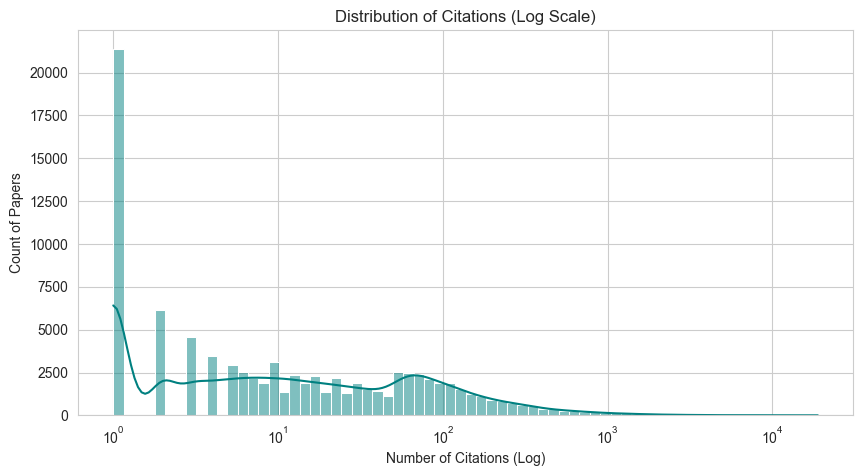

C:\Users\X0\AppData\Local\Temp\ipykernel_28108\299753942.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  auth_trend = sampled_df.groupby('year')['num_authors'].mean().reset_index()


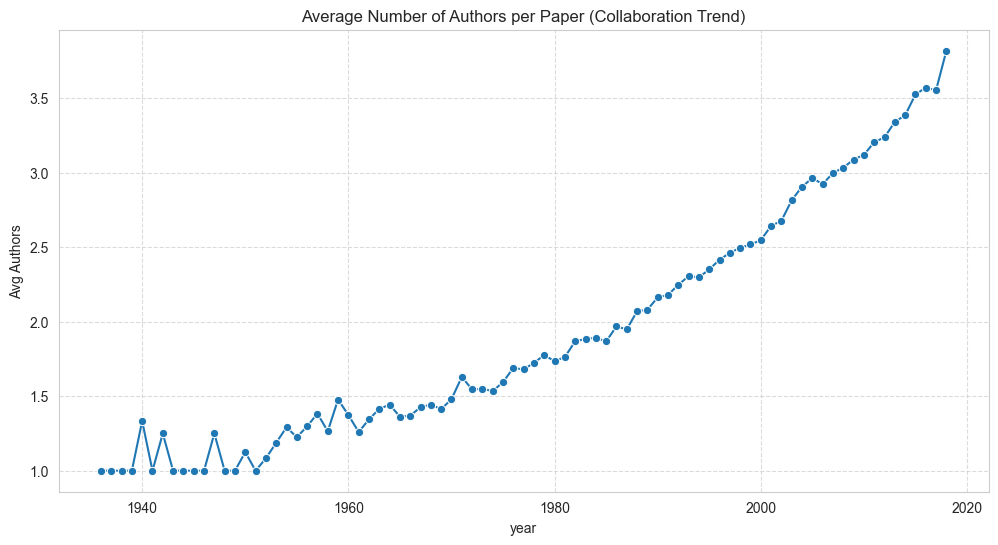

C:\Users\X0\AppData\Local\Temp\ipykernel_28108\299753942.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='venue', data=sampled_df[sampled_df['venue'].isin(top_venues)], order=top_venues, palette='viridis')


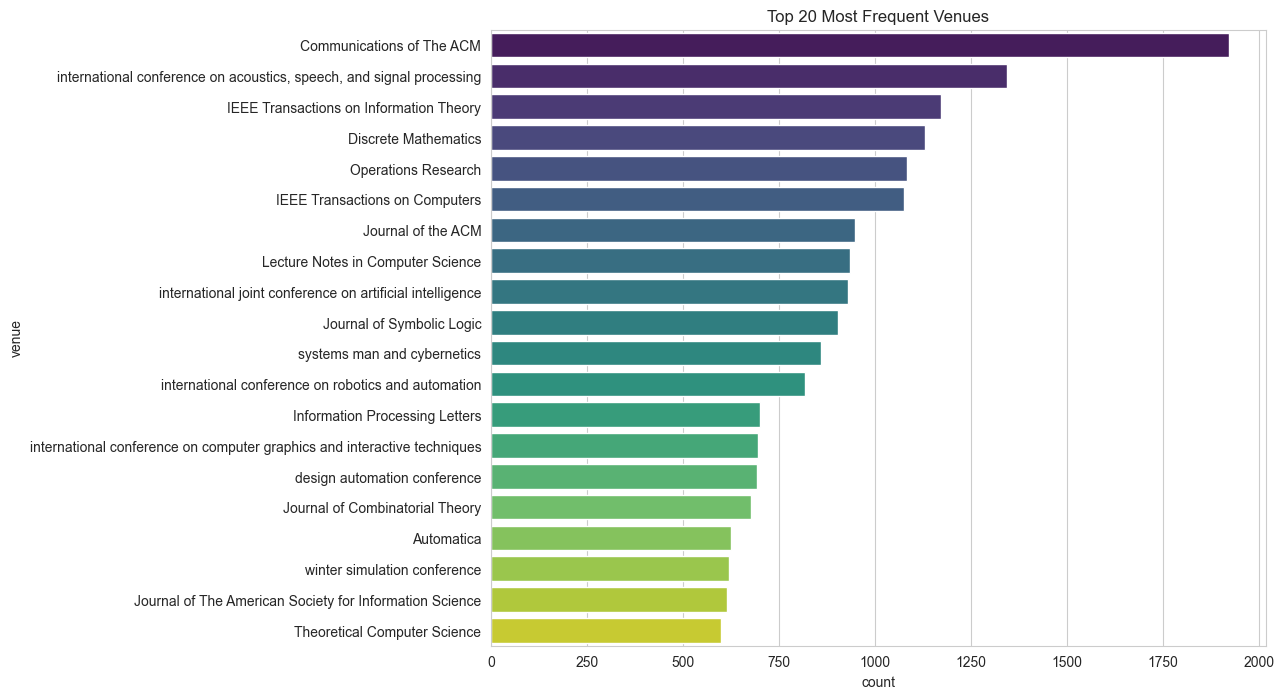

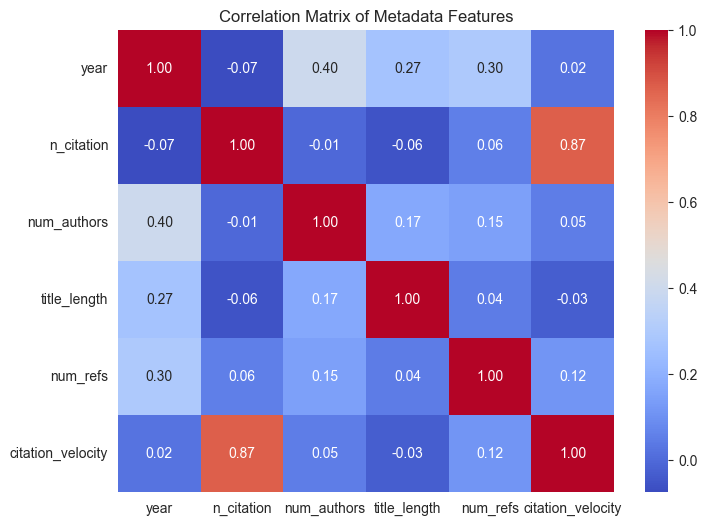

In [18]:
# The "Power Law" Check (Citation Distribution)
# See https://link.springer.com/article/10.1007/s100510050359
# This is now done above in the preprocessing check
# Preprocessed above to remove n_citation = 50 outlier
# ARTIFACT_VAL = 50
# clean_df = sampled_df[sampled_df['n_citation'] != ARTIFACT_VAL]

plt.figure(figsize=(10,5))
sns.histplot(sampled_df['n_citation'] + 1, log_scale=True, kde=True, color='teal')
plt.title('Distribution of Citations (Log Scale)')
plt.xlabel('Number of Citations (Log)')
plt.ylabel('Count of Papers')
plt.savefig(f"{FIGURE_SAVE_PATH}/eda_citation_distribution.png")
plt.show()

plt.figure(figsize=(12, 6))
# Group by year and get mean authors
auth_trend = sampled_df.groupby('year')['num_authors'].mean().reset_index()
sns.lineplot(data=auth_trend, x='year', y='num_authors', marker='o')
plt.title('Average Number of Authors per Paper (Collaboration Trend)')
plt.ylabel('Avg Authors')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(f"{FIGURE_SAVE_PATH}/eda_collaboration_trend.png")
plt.show()

plt.figure(figsize=(10, 8))
# Get top 20 venues
top_venues = sampled_df['venue'].value_counts().nlargest(20).index
# Filter data to only those venues for plotting
sns.countplot(y='venue', data=sampled_df[sampled_df['venue'].isin(top_venues)], order=top_venues, palette='viridis')
plt.title('Top 20 Most Frequent Venues')
plt.savefig(f"{FIGURE_SAVE_PATH}/eda_top_venues.png")
plt.show()



# Select only numeric metadata
meta_cols = ['year', 'n_citation', 'num_authors', 'title_length', 'num_refs', 'citation_velocity']

plt.figure(figsize=(8, 6))
sns.heatmap(sampled_df[meta_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Metadata Features')
plt.savefig(f"{FIGURE_SAVE_PATH}/eda_corr_matrix.png")
plt.show()


# Task 2: Topic Clustering

#### K-Means Pipeline

Important: You really only need to run this once

This is in an attempt to find an optimal low k in order to still make the clusters interpretable.

Testing k values (6-31)...
k=6: Silhouette=0.0456  Inertia=7398.8335
k=7: Silhouette=0.0615  Inertia=7288.7316
k=8: Silhouette=0.0721  Inertia=7101.7479
k=9: Silhouette=0.0594  Inertia=6985.3127
k=10: Silhouette=0.0920  Inertia=6884.1415
k=11: Silhouette=0.0714  Inertia=6717.9854
k=12: Silhouette=0.0651  Inertia=6560.8027
k=13: Silhouette=0.0706  Inertia=6480.6233
k=14: Silhouette=0.0742  Inertia=6361.1391
k=15: Silhouette=0.0673  Inertia=6255.8694
k=16: Silhouette=0.0773  Inertia=6129.6438
k=17: Silhouette=0.0805  Inertia=6038.6640
k=18: Silhouette=0.0792  Inertia=5963.7504
k=19: Silhouette=0.0952  Inertia=5809.9409
k=20: Silhouette=0.0849  Inertia=5738.6913
k=21: Silhouette=0.0722  Inertia=5654.5667
k=22: Silhouette=0.0843  Inertia=5566.4317
k=23: Silhouette=0.0814  Inertia=5485.1882
k=24: Silhouette=0.0851  Inertia=5397.0444
k=25: Silhouette=0.0974  Inertia=5311.4477
k=26: Silhouette=0.0875  Inertia=5223.5999
k=27: Silhouette=0.0898  Inertia=5183.6986
k=28: Silhouette=0.0930  Inerti

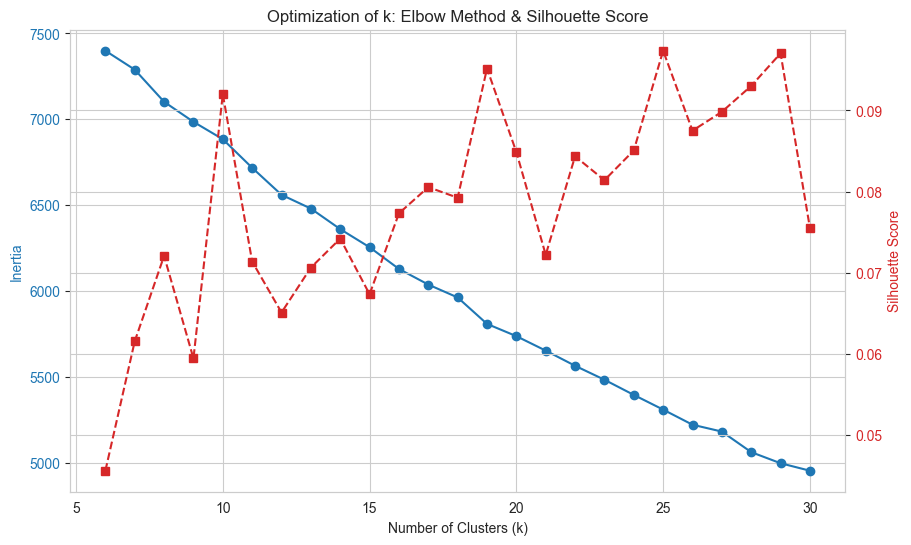

In [26]:

# We test k=6 to 20
# We use a SUBSET for Silhouette score because calculating it on 90k papers takes forever.
QUICK_TEST = False
MAX_CEILING = 31
ITER = 1 if QUICK_TEST else 5
k_range = range(6, MAX_CEILING)
inertias = []
sil_scores = []
sample_indices = np.random.choice(X_pca.shape[0], 15000, replace=False) # Test on 15k sample

print(f"Testing k values (6-{MAX_CEILING})...")
for k in k_range:
    temp_inertias = []
    temp_sil_scores = []
    for i in range(ITER):
        kmeans = KMeans(n_clusters=k, random_state=SAMPLE_SEED, n_init=5)
        labels = kmeans.fit_predict(X_pca)

        # Inertia (Elbow)
        temp_inertias.append(kmeans.inertia_)

        # Silhouette (Clustering Quality) - Closer to 1 is better
        score = silhouette_score(X_pca[sample_indices], labels[sample_indices])
        temp_sil_scores.append(score)

    inertias.append(np.mean(temp_inertias))
    sil_scores.append(np.mean(temp_sil_scores))

    print(f"k={k}: Silhouette={sil_scores[-1]:.4f}  Inertia={inertias[-1]:.4f}")

# Plot Results
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax1.plot(k_range, inertias, 'o-', color='tab:blue', label='Inertia')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='tab:red')
ax2.plot(k_range, sil_scores, 's--', color='tab:red', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Optimization of k: Elbow Method & Silhouette Score')
plt.grid(True)
plt.savefig(f"{FIGURE_SAVE_PATH}/topic_clustering_optimal_k.png")
plt.show()

We start to evaluate all topic clusterings based on keywords for k values 6-30 in order too see when the topics start to get overly fragmented as well

In [27]:
import numpy as np
from sklearn.cluster import KMeans

START_K = 6
END_K = 31
N_INIT = 10

feature_names = tfidf.get_feature_names_out()

# Store topic outputs for later comparison
all_topic_models = {}

print("Running topic extraction for K = 6 to 30...\n")

for K in range(START_K, END_K):
    print("="*70)
    print(f"Clustering into {K} topics...")

    # Run KMeans
    kmeans = KMeans(
        n_clusters=K,
        random_state=SAMPLE_SEED,
        n_init=N_INIT
    )
    labels = kmeans.fit_predict(X_pca)

    # store labels so we don’t overwrite sampled_df each iteration
    all_topic_models[K] = {
        'labels': labels,
        'clusters': {}
    }

    print("Extracting top keywords for each topic...")

    for cluster_id in range(K):

        # indices belonging to this cluster
        cluster_indices = np.where(labels == cluster_id)[0]

        # compute average TF-IDF vector
        cluster_mean = X_tfidf[cluster_indices].mean(axis=0)
        cluster_mean_arr = np.asarray(cluster_mean).flatten()

        # top 10 keyword indices
        top_indices = cluster_mean_arr.argsort()[::-1][:10]
        top_keywords = [feature_names[i] for i in top_indices]

        # sample paper title
        sample_title = sampled_df.iloc[cluster_indices[0]]["title"]

        # Store structured info
        all_topic_models[K]['clusters'][cluster_id] = {
            'size': len(cluster_indices),
            'keywords': top_keywords,
            'sample_title': sample_title
        }

        # Print like your original style
        print(f"\n--- Cluster {cluster_id} ({len(cluster_indices)} papers) ---")
        print(f"Keywords: {', '.join(top_keywords)}")
        print(f"Sample Title: {sample_title}")

    print("="*70)
    print("\n")


Running topic extraction for K = 6 to 30...

Clustering into 6 topics...
Extracting top keywords for each topic...

--- Cluster 0 (5766 papers) ---
Keywords: language, languages, programming, program, programs, logic, semantics, natural language, natural, programming language
Sample Title: contextual definitions in nonextensional languages

--- Cluster 1 (6543 papers) ---
Keywords: network, networks, neural, wireless, routing, traffic, performance, nodes, neural networks, neural network
Sample Title: on the input impedance network error in operational amplifiers

--- Cluster 2 (2595 papers) ---
Keywords: graph, graphs, vertices, vertex, edge, edges, connected, abstract, planar, directed
Sample Title: on the exceptional case in a characterization of the arcs of a complete graph

--- Cluster 3 (27538 papers) ---
Keywords: linear, algorithms, problems, set, optimal, function, given, functions, finite, order
Sample Title: finite combinatory processes--formulation 1

--- Cluster 4 (4123 pap

Choose k with well differentiated, interpretable topics based on above cell

In [45]:
import numpy as np
from sklearn.cluster import KMeans

OPTIMAL_K = 19 # We chose this k for interpretability and from the above output

# Fit Final Model
print(f"Clustering into {OPTIMAL_K} topics...")
# Use X_pca for the clustering itself (efficient)
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SAMPLE_SEED, n_init=10)
sampled_df['cluster'] = kmeans.fit_predict(X_pca)

# Interpret Clusters (Keyword Extraction)
print("Extracting top keywords for each topic...")

# We need the original TF-IDF vocabulary to convert numbers back to words
feature_names = tfidf.get_feature_names_out()

# Group papers by cluster
for i in range(OPTIMAL_K):
    # Get the indices of papers in this cluster
    cluster_indices = sampled_df[sampled_df['cluster'] == i].index

    # Calculate the AVERAGE TF-IDF vector for this cluster
    # (We use the X_tfidf matrix from Task 1, slicing by the cluster's rows)
    cluster_center = X_tfidf[cluster_indices].mean(axis=0)

    # Convert matrix to 1D array
    cluster_center_arr = np.asarray(cluster_center).flatten()

    # Get indices of the top 10 highest weighted words
    top_indices = cluster_center_arr.argsort()[::-1][:10]

    # Map indices to words
    top_keywords = [feature_names[ind] for ind in top_indices]

    print(f"\n--- Cluster {i} ({len(cluster_indices)} papers) ---")
    print(f"Keywords: {', '.join(top_keywords)}")
    # Show a sample title to verify
    print(f"Sample Title: {sampled_df[sampled_df['cluster'] == i]['title'].iloc[0]}")

Clustering into 19 topics...
Extracting top keywords for each topic...

--- Cluster 0 (14546 papers) ---
Keywords: problems, linear, algorithms, set, functions, finite, solution, function, optimal, given
Sample Title: finite combinatory processes--formulation 1

--- Cluster 1 (5404 papers) ---
Keywords: codes, signal, channel, error, noise, frequency, power, performance, estimation, filter
Sample Title: error-free coding

--- Cluster 2 (2055 papers) ---
Keywords: language, programming, natural language, natural, programming language, languages, program, semantics, programs, level
Sample Title: some programming techniques for the ermeth

--- Cluster 3 (2404 papers) ---
Keywords: graphs, graph, vertices, vertex, edge, edges, connected, abstract, planar, complete
Sample Title: on the exceptional case in a characterization of the arcs of a complete graph

--- Cluster 4 (1829 papers) ---
Keywords: parallel, algorithms, processors, memory, performance, processing, processor, parallel algorit

Visualize the clusters with new human-readable labels you might need to change the cluster_names list see above for the output result

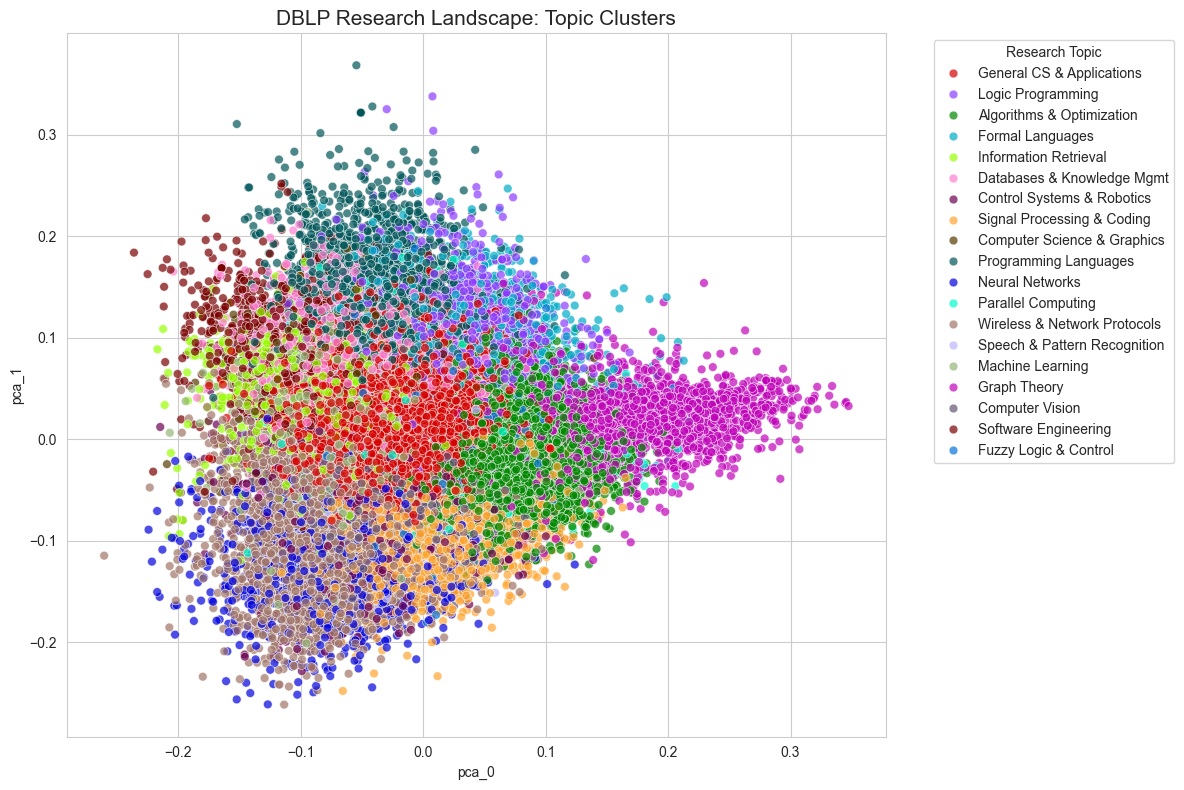

In [46]:
# Update cluster names based on the output we get above
cluster_names = {
    # --- THEORY & ALGORITHMS ---
    0: 'Algorithms & Optimization',      # problems, linear, algorithms, optimal, solution
    3: 'Graph Theory',                   # graphs, vertices, edge, planar, connected
    4: 'Parallel Computing',             # parallel, processors, algorithms, memory
    7: 'Logic Programming',              # logic, programs, modal, semantics, propositional
    16: 'Formal Languages',              # languages, grammars, context free, grammar

    # --- ARTIFICIAL INTELLIGENCE ---
    5: 'Machine Learning',               # learning, machine learning, training, classification
    6: 'Neural Networks',                # network, neural, neural networks, training
    11: 'Computer Vision',               # image, segmentation, color, motion, 3d
    14: 'Fuzzy Logic & Control',         # fuzzy, fuzzy logic, fuzzy sets, rules
    18: 'Speech & Pattern Recognition',  # speech recognition, speaker, acoustic, pattern

    # --- SYSTEMS & ENGINEERING ---
    1: 'Signal Processing & Coding',     # codes, signal, channel, error, noise, frequency
    8: 'Control Systems & Robotics',     # control, robot, adaptive, feedback, optimal control
    10: 'Wireless & Network Protocols',  # networks, routing, wireless, protocol, sensor, mobile
    15: 'Software Engineering',          # software engineering, process, hardware, testing

    # --- DATA & KNOWLEDGE ---
    2: 'Programming Languages',          # language, programming, natural language, semantics
    13: 'Information Retrieval',         # information retrieval, user, management, web, search
    17: 'Databases & Knowledge Mgmt',    # knowledge, database, query, relational, object oriented

    # --- INTERDISCIPLINARY ---
    9: 'Computer Science & Graphics',    # computer science, graphics, computer graphics, simulation

    # --- GENERAL/MIXED ---
    12: 'General CS & Applications'      # (The "Blob": performance, used, process, simulation, applications)
}

# For reference
hierarchy = {
    'Theory & Algorithms': [0, 3, 4, 7, 16],        # 5 clusters
    'Artificial Intelligence': [5, 6, 11, 14, 18],  # 5 clusters
    'Systems & Engineering': [1, 8, 10, 15],        # 4 clusters
    'Data & Knowledge': [2, 13, 17],                # 3 clusters
    'Interdisciplinary': [9],                        # 1 cluster
    'General': [12]                                  # 1 cluster (the blob)
}

# Apply the mapping
sampled_df['label'] = sampled_df['cluster'].map(cluster_names)

# Apply the mapping
sampled_df['label'] = sampled_df['cluster'].map(cluster_names)

# Apply mapping
sampled_df['label'] = sampled_df['cluster'].map(cluster_names)

# 3. Plot
palette = palette = cc.glasbey[:len(cluster_names)]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca_0',
    y='pca_1',
    hue='label',
    data=sampled_df,
    palette=palette,
    alpha=0.70,
    s=40             # Marker size
)
plt.title('DBLP Research Landscape: Topic Clusters', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Research Topic')
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/topic_clustering_pca.png")
plt.show()

Running t-SNE to visualize clusters (this takes a moment)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 90191 samples in 0.016s...
[t-SNE] Computed neighbors for 90191 samples in 5.476s...
[t-SNE] Computed conditional probabilities for sample 1000 / 90191
[t-SNE] Computed conditional probabilities for sample 2000 / 90191
[t-SNE] Computed conditional probabilities for sample 3000 / 90191
[t-SNE] Computed conditional probabilities for sample 4000 / 90191
[t-SNE] Computed conditional probabilities for sample 5000 / 90191
[t-SNE] Computed conditional probabilities for sample 6000 / 90191
[t-SNE] Computed conditional probabilities for sample 7000 / 90191
[t-SNE] Computed conditional probabilities for sample 8000 / 90191
[t-SNE] Computed conditional probabilities for sample 9000 / 90191
[t-SNE] Computed conditional probabilities for sample 10000 / 90191
[t-SNE] Computed conditional probabilities for sample 11000 / 90191
[t-SNE] Computed conditional probabilities for sample 12

C:\Users\X0\AppData\Local\Temp\ipykernel_28108\594032256.py:15: UserWarning: The palette list has more values (32) than needed (19), which may not be intended.
  sns.scatterplot(


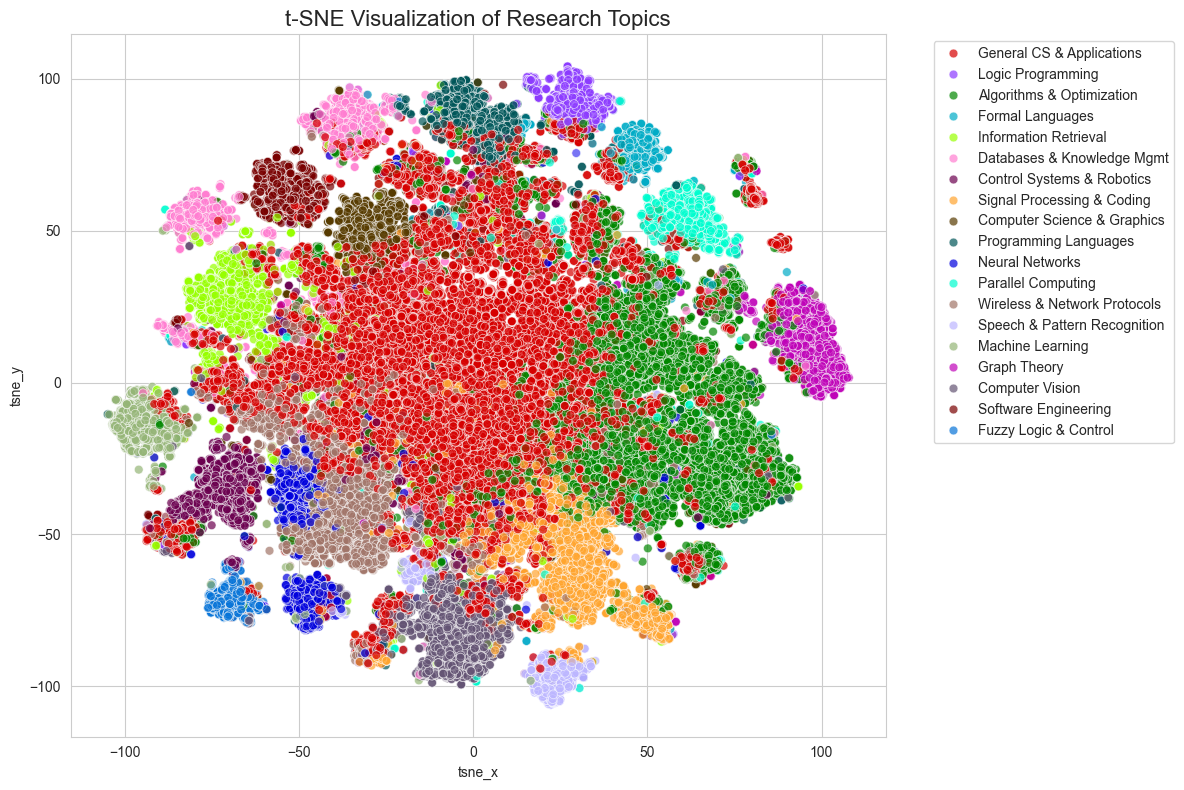

In [59]:
from sklearn.manifold import TSNE

print("Running t-SNE to visualize clusters (this takes a moment)...")

# We use the same X_pca data, but project it differently
tsne = TSNE(n_components=2, verbose=1, perplexity=40, random_state=SAMPLE_SEED)
tsne_results = tsne.fit_transform(X_pca)

# Add t-SNE results to the dataframe
sampled_df['tsne_x'] = tsne_results[:, 0]
sampled_df['tsne_y'] = tsne_results[:, 1]

# Plotting the t-SNE result
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    hue='label',
    data=sampled_df,
    palette=palette,
    alpha=0.7,
    s=40,
    legend='full'
)

plt.title('t-SNE Visualization of Research Topics', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/topic_clustering_t-SNE.png")
plt.show()

Checkpoint save and load dataset

In [103]:
save_split_dataframe(sampled_df, DATASET_PATH, DATASET_SAMPLE_NAME, n_parts = 10)

Saved rows [0:22548) to ./datasets\reproducible_dataset_part00.pkl
Saved rows [22548:45096) to ./datasets\reproducible_dataset_part01.pkl
Saved rows [45096:67644) to ./datasets\reproducible_dataset_part02.pkl
Saved rows [67644:90191) to ./datasets\reproducible_dataset_part03.pkl


In [4]:
sampled_df = load_split_dataframe(DATASET_PATH, DATASET_SAMPLE_NAME)

Tackling the blob (The big cluster) to see if we can subdivide it. First we start by trying to find the optimal k

Extracting Cluster 12 (the blob) for re-clustering...
Blob size: 34806 papers
Shape - TF-IDF: (34806, 5000), PCA: (34806, 50)

Testing k values for blob clustering...
k=5: Silhouette=0.0940  Inertia=1382.8678
k=6: Silhouette=0.0989  Inertia=1347.0449
k=7: Silhouette=0.0968  Inertia=1289.8005
k=8: Silhouette=0.1068  Inertia=1250.7393
k=9: Silhouette=0.1023  Inertia=1216.5739
k=10: Silhouette=0.1008  Inertia=1180.0700
k=11: Silhouette=0.1009  Inertia=1150.7966
k=12: Silhouette=0.1034  Inertia=1115.7667
k=13: Silhouette=0.1073  Inertia=1086.4778
k=14: Silhouette=0.1113  Inertia=1056.8738
k=15: Silhouette=0.1001  Inertia=1036.3715


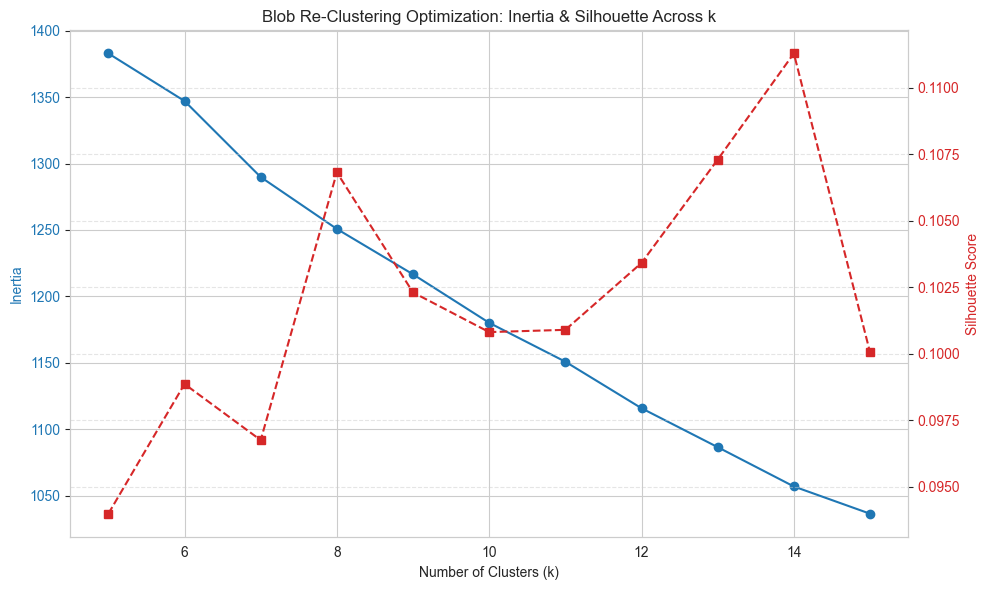

In [34]:
# Extract just the blob (Cluster)
print("Extracting Cluster 12 (the blob) for re-clustering...")
blob_mask = sampled_df['cluster'] == 12
blob_df = sampled_df[blob_mask].copy()
blob_indices = blob_df.index

# Get the corresponding TF-IDF and PCA representations
X_tfidf_blob = X_tfidf[blob_indices]
X_pca_blob = X_pca[blob_indices]

print(f"Blob size: {len(blob_df)} papers")
print(f"Shape - TF-IDF: {X_tfidf_blob.shape}, PCA: {X_pca_blob.shape}")

# Test different k values for the blob
print("\nTesting k values for blob clustering...")
from sklearn.metrics import silhouette_score

blob_k_range = range(5, 16)  # Test k=5 to k=15
blob_scores = []

for k in blob_k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=SAMPLE_SEED, n_init=10)
    labels = kmeans_test.fit_predict(X_pca_blob)

    silhouette = silhouette_score(X_pca_blob, labels)
    inertia = kmeans_test.inertia_

    blob_scores.append({'k': k, 'silhouette': silhouette, 'inertia': inertia})
    print(f"k={k}: Silhouette={silhouette:.4f}  Inertia={inertia:.4f}")


# Plot the results
ks = [d['k'] for d in blob_scores]
inertias = [d['inertia'] for d in blob_scores]
silhouettes = [d['silhouette'] for d in blob_scores]

fig, ax1 = plt.subplots(figsize=(10, 6))
# Inertia curve
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="tab:blue")
ax1.plot(ks, inertias, "o-", color="tab:blue", label="Inertia")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Silhouette curve (secondary axis)
ax2 = ax1.twinx()
ax2.set_ylabel("Silhouette Score", color="tab:red")
ax2.plot(ks, silhouettes, "s--", color="tab:red", label="Silhouette")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Title & presentation
plt.title("Blob Re-Clustering Optimization: Inertia & Silhouette Across k")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/topic_clustering_blob_optimal_k.png", dpi=300)
plt.show()

Choose optimal K for the blob (big cluster) based on the output above

In [73]:
# Choose optimal k for blob (pick based on output above)
BLOB_K = 14

print(f"Re-clustering blob into {BLOB_K} sub-topics...")
print(f"{'='*70}\n")

# Fit final model on blob
kmeans_blob = KMeans(n_clusters=BLOB_K, random_state=SAMPLE_SEED, n_init=10)
blob_df['sub_cluster'] = kmeans_blob.fit_predict(X_pca_blob)

# Extract keywords for blob sub-clusters
print("Extracting top keywords for each blob sub-topic...")
feature_names = tfidf.get_feature_names_out()

for i in range(BLOB_K):
    # Get indices within the blob dataframe
    sub_cluster_mask = blob_df['sub_cluster'] == i
    sub_cluster_df = blob_df[sub_cluster_mask]

    # Get the actual indices in the original data
    sub_cluster_indices = sub_cluster_df.index

    # Calculate average TF-IDF vector for this sub-cluster
    cluster_center = X_tfidf[sub_cluster_indices].mean(axis=0)
    cluster_center_arr = np.asarray(cluster_center).flatten()

    # Get top 10 keywords
    top_indices = cluster_center_arr.argsort()[::-1][:10]
    top_keywords = [feature_names[ind] for ind in top_indices]

    print(f"\n--- Blob Sub-Cluster {i} ({len(sub_cluster_df)} papers) ---")
    print(f"Keywords: {', '.join(top_keywords)}")
    print(f"Sample Title: {sub_cluster_df['title'].iloc[0]}")



Re-clustering blob into 14 sub-topics...

Extracting top keywords for each blob sub-topic...

--- Blob Sub-Cluster 0 (13521 papers) ---
Keywords: note, abstract, semantics, calculus, editor, reasoning, proof, certification, review, theorem
Sample Title: toward a calculus of concepts

--- Blob Sub-Cluster 1 (787 papers) ---
Keywords: simulation, modeling, event, discrete event, performance, discrete, process, manufacturing, used, agent
Sample Title: digital computers for real-time simulation

--- Blob Sub-Cluster 2 (796 papers) ---
Keywords: test, fault, testing, faults, circuits, generation, test generation, coverage, tests, circuit
Sample Title: a test for the existence of tautologies according to many-valued truth-tables

--- Blob Sub-Cluster 3 (1165 papers) ---
Keywords: user, interface, users, interactive, user interface, virtual, interaction, interfaces, environment, user interfaces
Sample Title: system engineering in an industrial environment

--- Blob Sub-Cluster 4 (655 papers) 

Update original dataframe with new labels

In [74]:
# Update original dataframe with new labels without destroying the original mini clusters we found
sampled_df[f'blob_k{BLOB_K}'] = np.nan
sampled_df.loc[blob_indices, f'blob_k{BLOB_K}'] = blob_df['sub_cluster']

Now we plot name new subclusters found in the blob and then merge both the previous cluster and the blob sub clusters

In [75]:
blob_subcluster_names = {
    0:  "Logic/Proof & Semantics Core",
    1:  "Discrete-Event Simulation & Modeling",
    2:  "Hardware Testing & Fault Diagnosis",
    3:  "User Interfaces & HCI",
    4:  "Web Search & Semantic Web Services",
    5:  "Memory & Cache Architectures",
    6:  "Decision Support & Business Processes",
    7:  "Mobile Robotics & Navigation",
    8:  "High-Performance Architectures & Scheduling",
    9:  "Extended Abstracts & Protocols",
    10: "Type & Recursion Theory",
    11: "Program Verification & Correctness",
    12: "Distributed Systems & Communication",
    13: "Detection, Structure & Object/Video Methods",
}

def assign_topic_label(row):
    global_id = row['cluster']
    blob_id = row['blob_k14']

    # If it's NOT in the blob, use the global name
    if global_id != 12:
        return cluster_names.get(global_id, f"Cluster {global_id}")

    # If it IS in the blob, and we have subcluster info, use refined name
    if pd.notna(blob_id):
        blob_id = int(blob_id)
        return blob_subcluster_names.get(blob_id, f"Blob Subtopic {blob_id}")

    # Fallback (should basically never happen)
    return "General CS & Applications (Unrefined)"

sampled_df['topic_label'] = sampled_df.apply(assign_topic_label, axis=1)

Checkpoint save and load sampled dataset

In [105]:
save_split_dataframe(sampled_df, DATASET_PATH, DATASET_SAMPLE_NAME, n_parts = 10)

Saved rows [0:9020) to ./datasets\reproducible_dataset_part00.pkl
Saved rows [9020:18040) to ./datasets\reproducible_dataset_part01.pkl
Saved rows [18040:27060) to ./datasets\reproducible_dataset_part02.pkl
Saved rows [27060:36080) to ./datasets\reproducible_dataset_part03.pkl
Saved rows [36080:45100) to ./datasets\reproducible_dataset_part04.pkl
Saved rows [45100:54120) to ./datasets\reproducible_dataset_part05.pkl
Saved rows [54120:63140) to ./datasets\reproducible_dataset_part06.pkl
Saved rows [63140:72160) to ./datasets\reproducible_dataset_part07.pkl
Saved rows [72160:81180) to ./datasets\reproducible_dataset_part08.pkl
Saved rows [81180:90191) to ./datasets\reproducible_dataset_part09.pkl


In [10]:
sampled_df = load_split_dataframe(DATASET_PATH, DATASET_SAMPLE_NAME)

In [137]:
sampled_df.head(10)

,year,abstract,authors,n_citation,references,title,venue,id,text,num_authors,...,pca_46,pca_47,pca_48,pca_49,cluster,label,tsne_x,tsne_y,blob_k14,topic_label
0,1936,,[W. V. Quine],19,NaN,toward a calculus of concepts,Journal of Symbolic Logic,566fc941-6ba6-41ab-b579-ad3d7fe4ca27,Toward a calculus of concepts,1,...,0.002952,0.017808,0.008910,-0.010326,12,General CS & Applications,26.144827,29.181383,0.0,Logic/Proof & Semantics Core
1,1936,,[Frederic B. Fitch],24,[],a system of formal logic without an analogue t...,Journal of Symbolic Logic,62c68236-b9e5-44dd-b299-e0d03c3e7bf4,A System of Formal Logic without an Analogue t...,1,...,0.019213,0.006718,-0.022645,-0.019774,7,Logic Programming,29.045454,93.968498,NaN,Logic Programming
2,1936,,[Emil L. Post],367,[],finite combinatory processes--formulation 1,Journal of Symbolic Logic,e254cbb5-e369-49dc-97a2-4d60eaea27dd,Finite Combinatory Processes--Formulation 1,1,...,-0.012288,-0.048536,0.038909,0.053052,0,Algorithms & Optimization,53.042477,30.663332,NaN,Algorithms & Optimization
3,1936,,[J. Barkley Rosser],1,NaN,constructibility as a criterion for existence,Journal of Symbolic Logic,8581f824-2333-4b5f-b277-a4020281a7f8,Constructibility as a Criterion for Existence,1,...,-0.000098,0.001151,0.002429,-0.010975,12,General CS & Applications,28.988430,9.766901,0.0,Logic/Proof & Semantics Core
4,1936,,[Alonzo Church],150,[c45bdb20-3d36-4d7d-8a83-203e3d3bff9e],correction to a note on the entscheidungsproblem,Journal of Symbolic Logic,c5c32b04-0a67-4cd6-b135-3f65ab87e33b,Correction to a Note on the Entscheidungsproblem,1,...,-0.033541,-0.083212,0.039810,-0.026251,12,General CS & Applications,89.279663,46.457516,0.0,Logic/Proof & Semantics Core
5,1936,,[Alonzo Church],949,[],a note on the entscheidungsproblem,Journal of Symbolic Logic,c45bdb20-3d36-4d7d-8a83-203e3d3bff9e,A Note on the Entscheidungsproblem,1,...,-0.053481,-0.105636,0.066998,-0.049147,12,General CS & Applications,90.358742,47.006649,0.0,Logic/Proof & Semantics Core
6,1937,,[A. M. Turing],552,[],computability and λ-definability,Journal of Symbolic Logic,0ae42956-0f17-4fd8-9453-baf2d0961c1a,Computability and λ-definability,1,...,0.003440,-0.000305,-0.001626,-0.000838,12,General CS & Applications,11.590981,18.674372,0.0,Logic/Proof & Semantics Core
7,1937,,[A. M. Turing],4,[],the þ-function in λ-k-conversion,Journal of Symbolic Logic,2c4c81e4-53d5-43d9-b82f-a230e22c2378,The þ-function in λ-K-conversion,1,...,0.049571,-0.020171,0.016983,0.058341,0,Algorithms & Optimization,72.428162,-5.026690,NaN,Algorithms & Optimization
8,1937,,[B. A. Bernstein],1,[],remark on nicod's reduction of principia mathe...,Journal of Symbolic Logic,fb61c692-822a-4541-9986-6ad4bf485251,Remark on Nicod's Reduction of Principia Mathe...,1,...,0.000834,0.002287,0.005528,0.006706,12,General CS & Applications,8.794024,9.725638,0.0,Logic/Proof & Semantics Core
9,1937,,[Haskell B. Curry],6,NaN,on the use of dots as brackets in logical expr...,Journal of Symbolic Logic,41f5e18d-db3d-4649-8e2e-c9f3d3e36196,On the Use of Dots as Brackets in Logical Expr...,1,...,0.011274,0.004294,-0.010729,0.005285,12,General CS & Applications,20.777786,26.796165,0.0,Logic/Proof & Semantics Core


Plot PCA

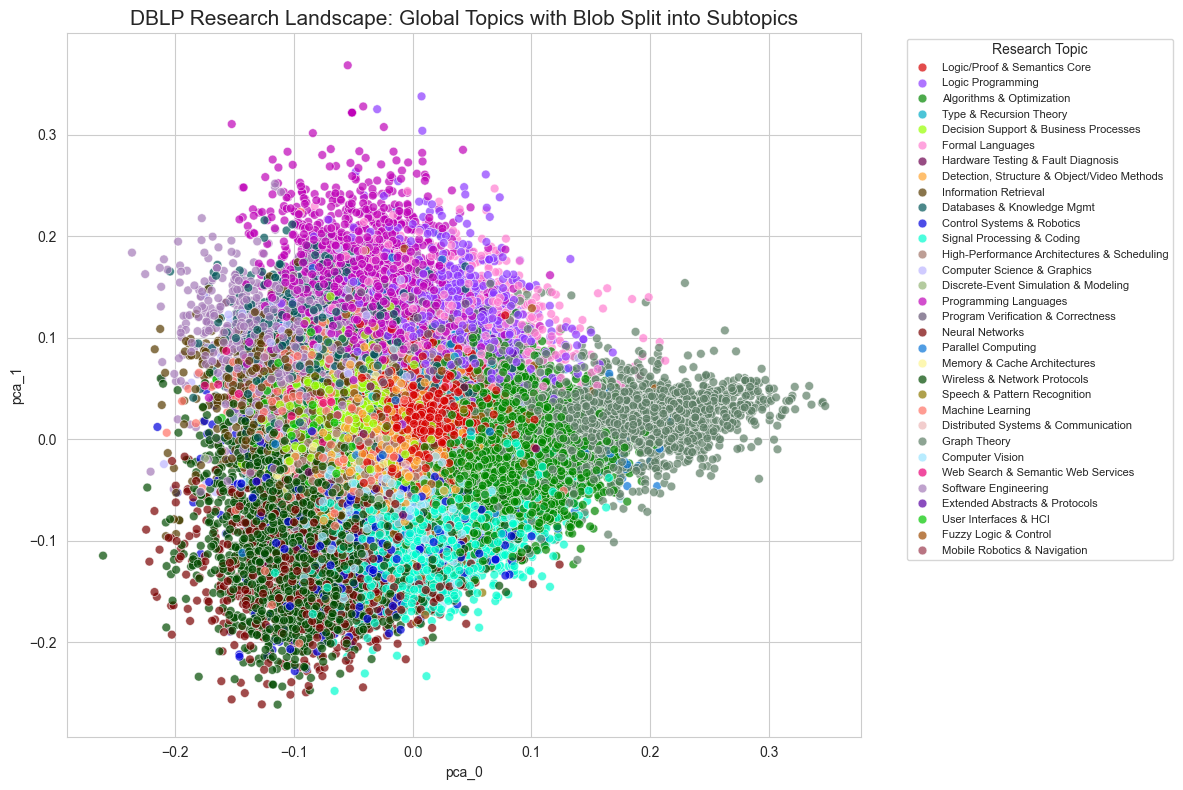

In [77]:
unique_labels = sampled_df['topic_label'].unique()
palette = cc.glasbey[:len(unique_labels)]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca_0',
    y='pca_1',
    hue='topic_label',
    data=sampled_df,
    palette=palette,
    alpha=0.7,
    s=40,
)
plt.title('DBLP Research Landscape: Global Topics with Blob Split into Subtopics', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Research Topic', fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/topic_clustering_pca_refined.png", dpi=300)
plt.show()


T-SNE with refined topics

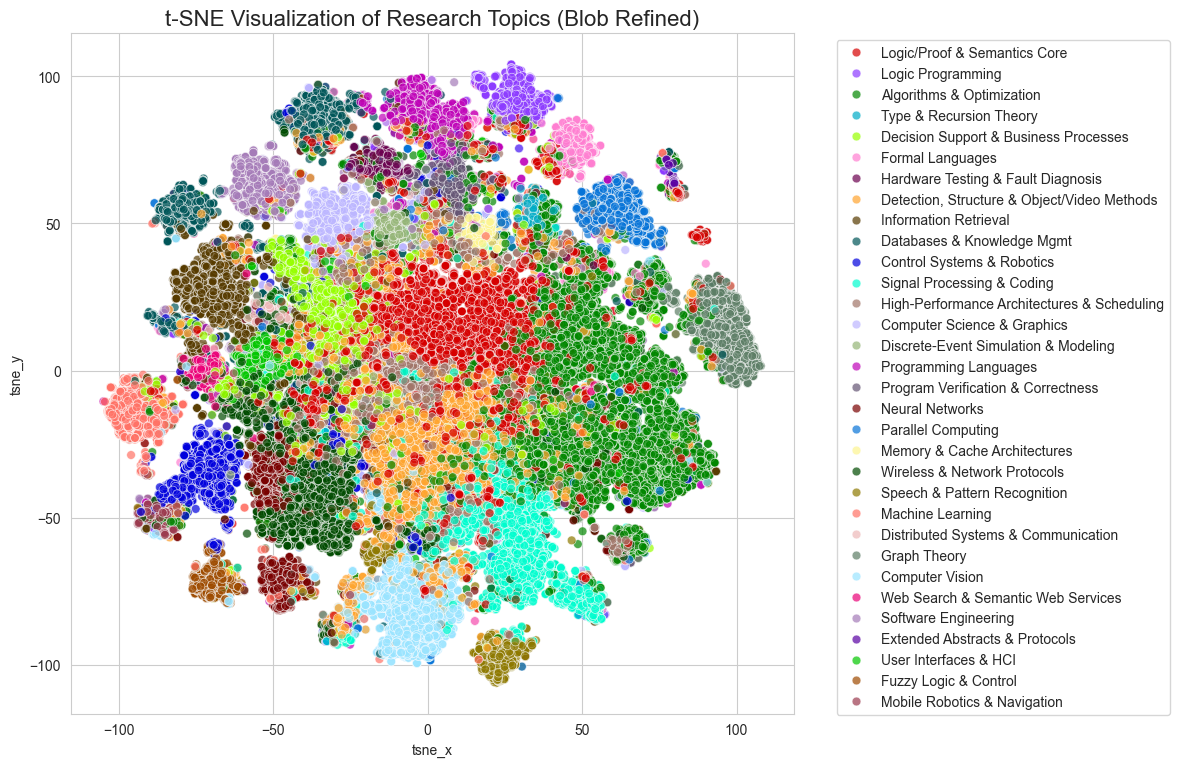

In [78]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='tsne_x',
    y='tsne_y',
    hue='topic_label',
    data=sampled_df,
    palette=palette,
    alpha=0.7,
    s=40,
    legend='full'
)
plt.title('t-SNE Visualization of Research Topics (Blob Refined)', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/topic_clustering_tsne_refined.png")
plt.show()


# Task 3: Temporal Trend Analysis

Create Super Topics and map it to the dataframe

In [29]:
sampled_df['year'] = pd.to_datetime(sampled_df['year'].astype(str))
print(sampled_df['year'].dtype)
sampled_df['year'].min()

datetime64[ns]


Timestamp('1936-01-01 00:00:00')

In [23]:
super_category_map = {
    # --- Theory & Algorithms ---
    "Algorithms & Optimization": "Theory & Algorithms",
    "Graph Theory": "Theory & Algorithms",
    "Logic Programming": "Theory & Algorithms",
    "Formal Languages": "Theory & Algorithms",
    "Type & Recursion Theory": "Theory & Algorithms",
    "Logic/Proof & Semantics Core": "Theory & Algorithms",
    "Program Verification & Correctness": "Theory & Algorithms",
    "Programming Languages": "Theory & Algorithms",
    "Extended Abstracts & Protocols": "Theory & Algorithms",

    # --- Artificial Intelligence ---
    "Machine Learning": "Artificial Intelligence",
    "Neural Networks": "Artificial Intelligence",
    "Computer Vision": "Artificial Intelligence",
    "Fuzzy Logic & Control": "Artificial Intelligence",
    "Speech & Pattern Recognition": "Artificial Intelligence",
    "Detection, Structure & Object/Video Methods": "Artificial Intelligence",

    # --- Systems & Engineering ---
    "Signal Processing & Coding": "Systems & Engineering",
    "High-Performance Architectures & Scheduling": "Systems & Engineering",
    "Software Engineering": "Systems & Engineering",
    "Hardware Testing & Fault Diagnosis": "Systems & Engineering",
    "Memory & Cache Architectures": "Systems & Engineering",
    "Discrete-Event Simulation & Modeling": "Systems & Engineering",
    "Decision Support & Business Processes": "Systems & Engineering",
    "Parallel Computing": "Systems & Engineering",

    # --- Data & Knowledge ---
    "Information Retrieval": "Data & Knowledge",
    "Databases & Knowledge Mgmt": "Data & Knowledge",
    "Web Search & Semantic Web Services": "Data & Knowledge",

    # --- Interdisciplinary / Graphics ---
    "Computer Science & Graphics": "Interdisciplinary / Graphics",
    "User Interfaces & HCI": "Interdisciplinary / Graphics",

    # --- Networks & Distributed ---
    "Wireless & Network Protocols": "Networks & Distributed",
    "Distributed Systems & Communication": "Networks & Distributed",

    # --- Robotics specializations ---
    "Mobile Robotics & Navigation": "Robotics & Control",
    "Control Systems & Robotics": "Robotics & Control",

}

sampled_df["super_topic"] = sampled_df["topic_label"].map(super_category_map)

In [24]:
# Group by year and super_topic
super_trends = (
    sampled_df
    .groupby(["year", "super_topic"])
    .size()
    .reset_index(name="n_papers")
)

# Pivot to wide format: rows = year, columns = super_topic
super_trends_wide = super_trends.pivot(index="year", columns="super_topic", values="n_papers").fillna(0)

print(super_trends_wide.head())


super_topic  Artificial Intelligence  Data & Knowledge  \
year                                                     
1936-01-01                       0.0               0.0   
1937-01-01                       0.0               0.0   
1938-01-01                       0.0               0.0   
1939-01-01                       0.0               0.0   
1940-01-01                       0.0               0.0   

super_topic  Interdisciplinary / Graphics  Networks & Distributed  \
year                                                                
1936-01-01                            0.0                     0.0   
1937-01-01                            0.0                     0.0   
1938-01-01                            0.0                     0.0   
1939-01-01                            0.0                     0.0   
1940-01-01                            0.0                     0.0   

super_topic  Robotics & Control  Systems & Engineering  Theory & Algorithms  
year                           

Plot the Macro Trend Freatures

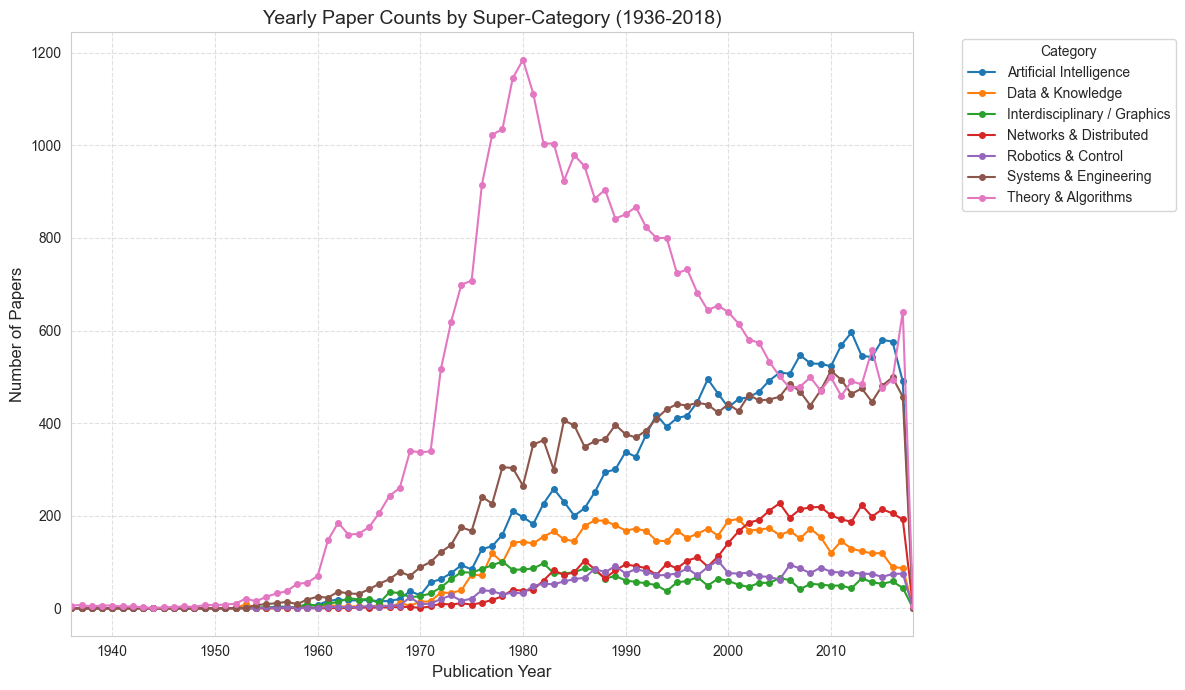

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot the filtered data
for col in super_trends_wide.columns:
    plt.plot(super_trends_wide.index, super_trends_wide[col], label=col, marker='o', markersize=4)

plt.xlim(left=pd.Timestamp('1936-01-01'), right=pd.Timestamp('2018-01-01'))
plt.xlabel("Publication Year", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)
plt.title("Yearly Paper Counts by Super-Category (1936-2018)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Category")

plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/temporal_super_topics.png", dpi=300)
plt.show()

Normalize by total papers per year

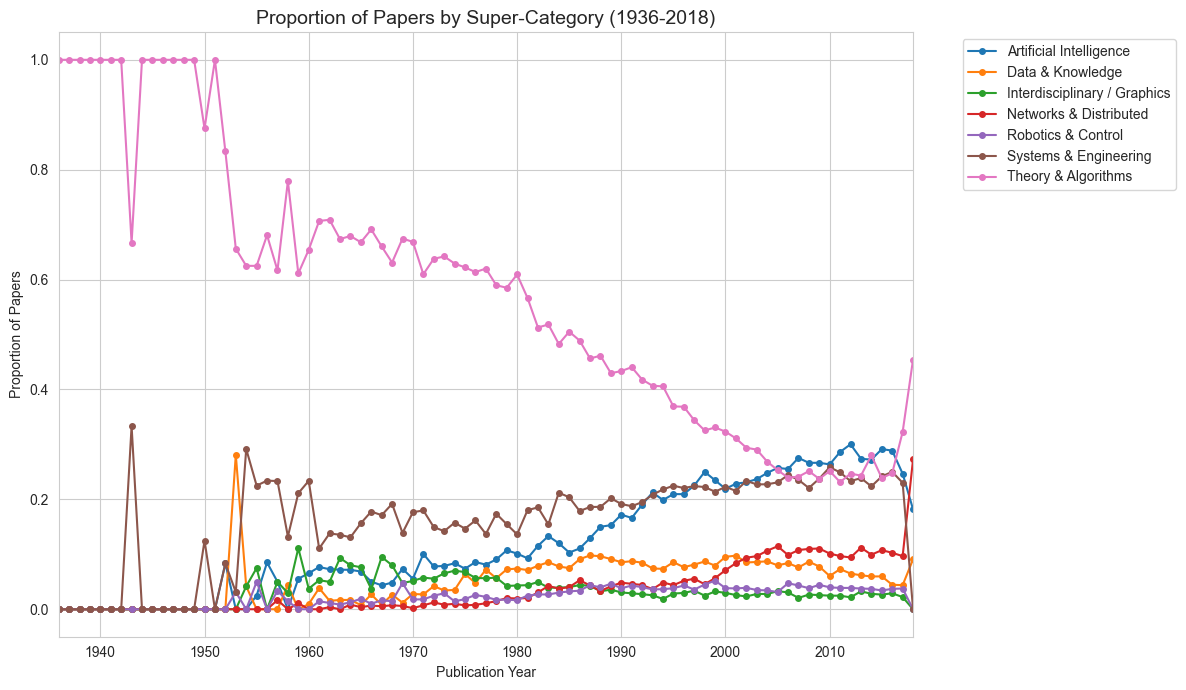

In [69]:
# Normalize super_trends_wide by row sums to get proportions
super_trends_prop = super_trends_wide.div(super_trends_wide.sum(axis=1), axis=0)

plt.figure(figsize=(12, 7))
for col in super_trends_prop.columns:
    plt.plot(super_trends_prop.index, super_trends_prop[col], label=col, marker='o', markersize=4)

plt.xlim(left=pd.Timestamp('1936-01-01'), right=pd.Timestamp('2018-01-01'))
plt.xlabel("Publication Year")
plt.ylabel("Proportion of Papers")
plt.title("Proportion of Papers by Super-Category (1936-2018)", fontsize=14 )
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/temporal_super_topics_share.png", dpi=300)
plt.show()


Yearly Trend for all 32 subtopics (fine-grained)

In [58]:
topic_trends = (
    sampled_df
    .groupby(["year", "topic_label"])
    .size()
    .reset_index(name="n_papers")
)

topic_trends_wide = topic_trends.pivot(index="year", columns="topic_label", values="n_papers").fillna(0)

print(topic_trends_wide.head())
print("Number of topic columns:", topic_trends_wide.shape[1])


topic_label  Algorithms & Optimization  Computer Science & Graphics  \
year                                                                  
1936-01-01                         1.0                          0.0   
1937-01-01                         1.0                          0.0   
1938-01-01                         1.0                          0.0   
1939-01-01                         2.0                          0.0   
1940-01-01                         0.0                          0.0   

topic_label  Computer Vision  Control Systems & Robotics  \
year                                                       
1936-01-01               0.0                         0.0   
1937-01-01               0.0                         0.0   
1938-01-01               0.0                         0.0   
1939-01-01               0.0                         0.0   
1940-01-01               0.0                         0.0   

topic_label  Databases & Knowledge Mgmt  \
year                                  

Compute Growth Metrics to pick Interesting Subtopics

In [57]:
# Define time windows for growth comparison
early_start, early_end = 1990, 2000
late_start, late_end   = 2010, 2020

# Subset the topic trends for each window
early_mask = (topic_trends["year"].dt.year >= early_start) & (topic_trends["year"].dt.year <= early_end)
late_mask  = (topic_trends["year"].dt.year >= late_start) & (topic_trends["year"].dt.year <= late_end)

early_avg = (
    topic_trends[early_mask]
    .groupby("topic_label")["n_papers"]
    .mean()
    .rename("early_avg")
)

late_avg = (
    topic_trends[late_mask]
    .groupby("topic_label")["n_papers"]
    .mean()
    .rename("late_avg")
)

growth_df = (
    pd.concat([early_avg, late_avg], axis=1)
    .fillna(0)
)

growth_df["growth_ratio"] = growth_df["late_avg"] / (growth_df["early_avg"] + 1)
topic_sizes = sampled_df["topic_label"].value_counts().rename("total_papers")
growth_df = growth_df.join(topic_sizes, how="left")

# Sort: biggest growth among topics that are not tiny
growth_df_sorted = growth_df.sort_values("growth_ratio", ascending=False)
print(growth_df_sorted.head(15))


                                              early_avg    late_avg  \
topic_label                                                           
Web Search & Semantic Web Services             8.909091   24.625000   
Decision Support & Business Processes         62.636364  131.000000   
Wireless & Network Protocols                  85.363636  174.888889   
Machine Learning                              39.272727   66.125000   
Detection, Structure & Object/Video Methods  146.636364  241.000000   
Signal Processing & Coding                    95.818182  152.625000   
User Interfaces & HCI                         25.454545   39.000000   
Fuzzy Logic & Control                         21.636364   27.375000   
High-Performance Architectures & Scheduling   85.636364   98.375000   
Computer Vision                               95.818182  104.250000   
Control Systems & Robotics                    59.272727   60.000000   
Discrete-Event Simulation & Modeling          19.272727   18.250000   
Neural

In [56]:
# pick top 8 by growth_ratio but require >= 500 papers total
interesting_topics = (
    growth_df[growth_df["total_papers"] >= 500]
    .sort_values("growth_ratio", ascending=False)
    .head(8)
    .index
    .tolist()
)

print("Selected subtopics for detailed plots:", interesting_topics)

Selected subtopics for detailed plots: ['Web Search & Semantic Web Services', 'Decision Support & Business Processes', 'Wireless & Network Protocols', 'Machine Learning', 'Detection, Structure & Object/Video Methods', 'Signal Processing & Coding', 'User Interfaces & HCI', 'Fuzzy Logic & Control']


Plot Temporal Trends for Selected Subtopics

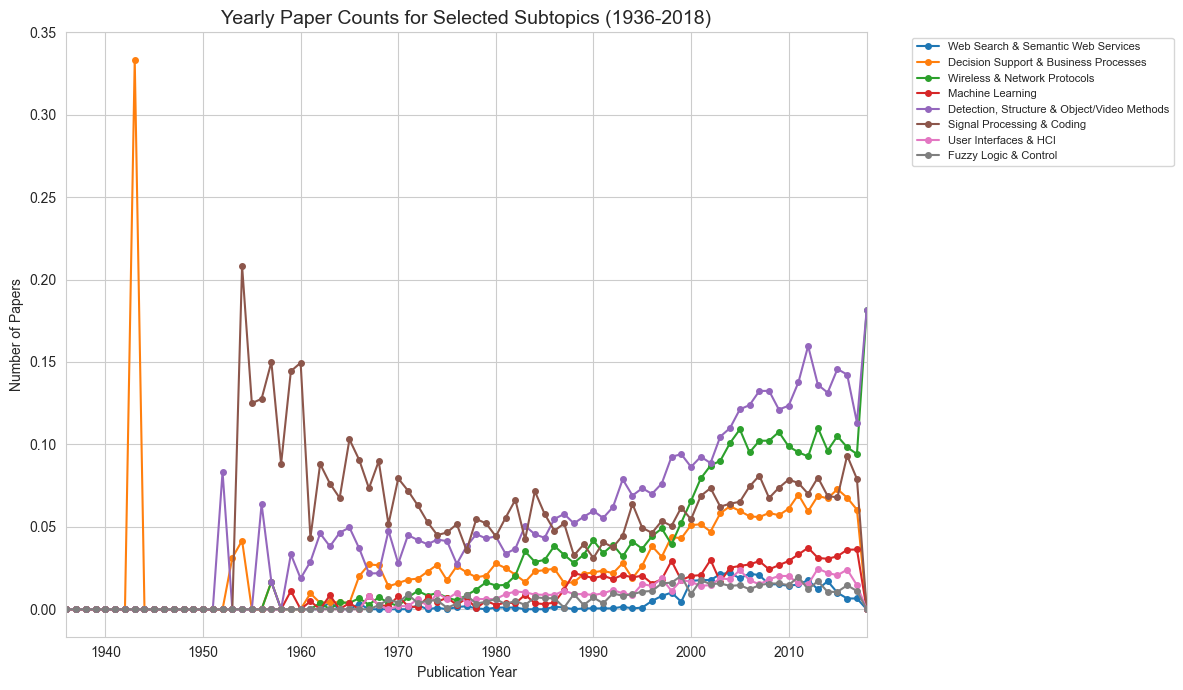

In [70]:
# Ensure we only pick topics that exist as columns
interesting_topics = [t for t in interesting_topics if t in topic_trends_wide.columns]

plt.figure(figsize=(12, 7))
for t in interesting_topics:
    plt.plot(topic_trends_wide.index, topic_trends_wide[t], label=t,  marker='o', markersize=4)

plt.xlim(left=pd.Timestamp('1936-01-01'), right=pd.Timestamp('2018-01-01'))
plt.xlabel("Publication Year")
plt.ylabel("Number of Papers")
plt.title("Yearly Paper Counts for Selected Subtopics (1936-2018)", fontsize=14 )
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/temporal_selected_subtopics.png", dpi=300)
plt.show()


Normalize by total papers per year

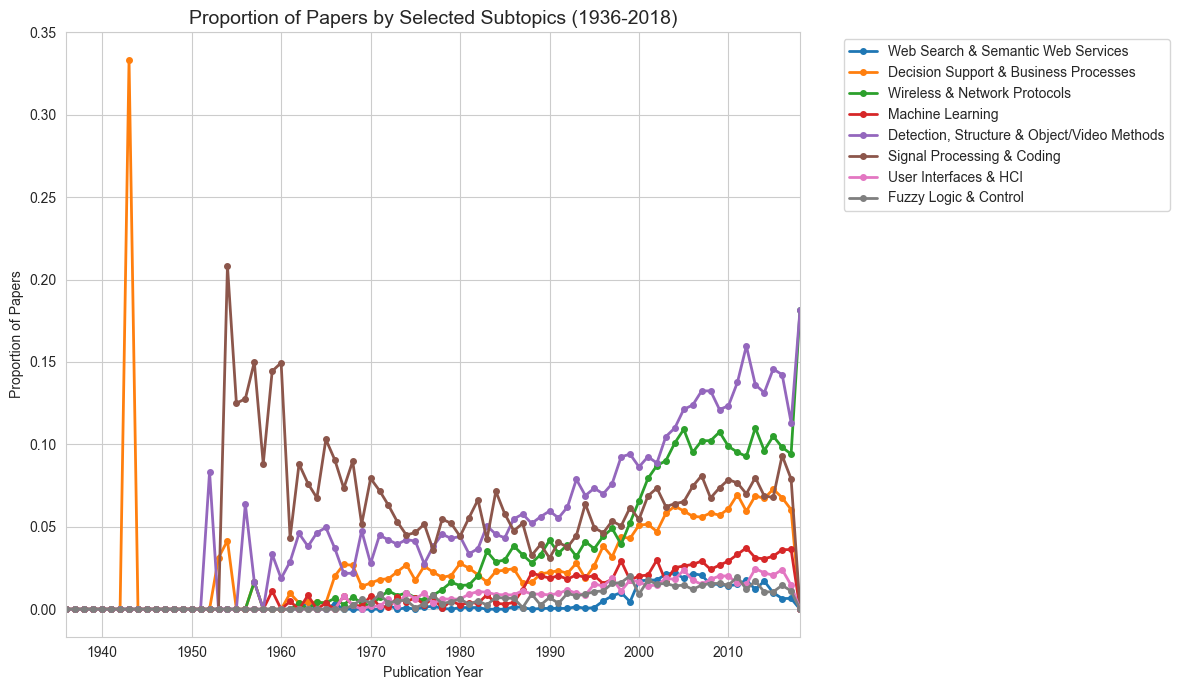

In [82]:
# Normalize super_trends_wide by row sums to get proportions
topic_trends_wide = topic_trends_wide.div(topic_trends_wide.sum(axis=1), axis=0)
valid_topics = [t for t in interesting_topics if t in topic_trends_wide.columns]

plt.figure(figsize=(12, 7))
for t in valid_topics:
    plt.plot(
        topic_trends_wide.index,
        topic_trends_wide[t],
        label=t,
        marker='o',
        markersize=4,
        linewidth=2
    )

plt.xlim(left=pd.Timestamp('1936-01-01'), right=pd.Timestamp('2018-01-01'))
plt.xlabel("Publication Year")
plt.ylabel("Proportion of Papers")
plt.title("Proportion of Papers by Selected Subtopics (1936-2018)", fontsize=14 )
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/temporal_subtopics_share.png", dpi=300)
plt.show()


# Task 4: Predictive Modeling (Classification)

We will begin to do hierarchical classification better known as a multi stage classifier. Our classifier will have two stages

Stage 1: Train a model using SVM to identify what major label a paper falls into (6 labels)

- Theory & Algorithms (5 subtopics)
- Artificial Intelligence (5 subtopics + subcluster refinements)
- Systems & Engineering
- Data & Knowledge
- Interdisciplinary
- Blob Subtopics (14 from above analysis)

Stage 2: Within the predicted category, we will train individual logistic regression models for each sub topic to predict the fine-grained topic. For an example if the Stage 1 model predicts Artificial Intelligence, the Stage 2 model only sees the AI-related papers and predicts:

- Machine Learning
- Neural Networks
- Computer Logic
- Fuzzy Logic & Control
- Speech & Pattern Recognition
- Object/Video Detection (blob subtopic)

This will reduce the model's job from picking between 32 topics to picking between 4-14 depending on the branch


Common code & imports for this task

Libraries

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_validate
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import  ComplementNB
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import time


Constants and helper functions

In [11]:
super_category_map = {
    # --- Theory & Algorithms ---
    "Algorithms & Optimization":          "Theory & Algorithms",
    "Graph Theory":                       "Theory & Algorithms",
    "Logic Programming":                  "Theory & Algorithms",
    "Formal Languages":                   "Theory & Algorithms",
    "Type & Recursion Theory":            "Theory & Algorithms",
    "Logic/Proof & Semantics Core":       "Theory & Algorithms",
    "Program Verification & Correctness": "Theory & Algorithms",
    "Programming Languages":              "Theory & Algorithms",
    "Extended Abstracts & Protocols":     "Theory & Algorithms",

    # --- Artificial Intelligence ---
    "Machine Learning":                   "Artificial Intelligence",
    "Neural Networks":                    "Artificial Intelligence",
    "Computer Vision":                    "Artificial Intelligence",
    "Fuzzy Logic & Control":              "Artificial Intelligence",
    "Speech & Pattern Recognition":       "Artificial Intelligence",
    "Detection, Structure & Object/Video Methods": "Artificial Intelligence",

    # --- Systems & Engineering ---
    "Signal Processing & Coding":         "Systems & Engineering",
    "High-Performance Architectures & Scheduling": "Systems & Engineering",
    "Software Engineering":               "Systems & Engineering",
    "Hardware Testing & Fault Diagnosis": "Systems & Engineering",
    "Memory & Cache Architectures":       "Systems & Engineering",
    "Discrete-Event Simulation & Modeling": "Systems & Engineering",
    "Decision Support & Business Processes": "Systems & Engineering",
    "Parallel Computing":                 "Systems & Engineering",


    # --- Data & Knowledge ---
    "Information Retrieval":              "Data & Knowledge",
    "Databases & Knowledge Mgmt":         "Data & Knowledge",
    "Web Search & Semantic Web Services": "Data & Knowledge",

    # --- Interdisciplinary / Graphics ---
    "Computer Science & Graphics":        "Interdisciplinary / Graphics",
    "User Interfaces & HCI":              "Interdisciplinary / Graphics",

    # --- Networks & Distributed ---
    "Wireless & Network Protocols":       "Networks & Distributed",
    "Distributed Systems & Communication":"Networks & Distributed",

    # --- Robotics specializations ---
    "Mobile Robotics & Navigation":       "Robotics & Control",
    "Control Systems & Robotics":         "Robotics & Control",

}

# We split the needed columns from sampled_df to a new dataframe for less memory usage
classification_df = pd.DataFrame()
classification_df['super_label'] = sampled_df['topic_label'].map(super_category_map)
classification_df['topic_label'] = sampled_df['topic_label']
classification_df['title'] = sampled_df['title']

X = X_tfidf # (90191, 5000) matrix
y_topic = sampled_df['topic_label'].to_numpy()
y_super = classification_df['super_label'].to_numpy()

# Train/Test Split
X_train, X_test, y_topic_train, y_topic_test, y_super_train, y_super_test = train_test_split(
    X, y_topic, y_super,
    test_size=0.2,
    random_state=SAMPLE_SEED,
    stratify=y_topic      # preserve per-topic proportions
)

# Helper function to get evaluation scores
def evaluate_classifier(model, X_test, y_test, title = "Model Evaluation"):
    y_pred = model.predict(X_test)
    print(f"\n===== {title} =====")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    print("\nClassification Report (Macro-F1 emphasizes small classes):")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

    return y_pred, cm


Checkpoint save and load subset dataframe

In [14]:
save_split_dataframe(
    classification_df,
    DATASET_PATH,
    'classification_df',
    n_parts = 4
)

Saved rows [0:22548) to ./datasets\classification_df_part00.pkl
Saved rows [22548:45096) to ./datasets\classification_df_part01.pkl
Saved rows [45096:67644) to ./datasets\classification_df_part02.pkl
Saved rows [67644:90191) to ./datasets\classification_df_part03.pkl


In [5]:
classification_df = load_split_dataframe(DATASET_PATH, 'classification_df')

Stage 1: The Baseline Classifier (Linear SVM)

In [ ]:
# Baseline Classifier (Linear SVM)
# clf_super = LinearSVC(class_weight="balanced", random_state=SAMPLE_SEED)
clf_super = lgb.LGBMClassifier(
    num_leaves=64,
    n_estimators=300,
    learning_rate=0.05,
    random_state=SAMPLE_SEED
)

clf_super.fit(X_train, y_super_train)
# Previous LinearSVM accuracy 84.96%

Evaluate Stage 1:

C:\Users\X0\Downloads\data-science-project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== Model Evaluation =====
Accuracy: 0.8988

Classification Report (Macro-F1 emphasizes small classes):
                              precision    recall  f1-score   support

     Artificial Intelligence       0.88      0.87      0.88      3402
            Data & Knowledge       0.94      0.91      0.92      1315
Interdisciplinary / Graphics       0.89      0.85      0.87       640
      Networks & Distributed       0.91      0.88      0.90      1077
          Robotics & Control       0.93      0.91      0.92       622
       Systems & Engineering       0.85      0.88      0.86      3695
         Theory & Algorithms       0.92      0.93      0.92      7288

                    accuracy                           0.90     18039
                   macro avg       0.90      0.89      0.90     18039
                weighted avg       0.90      0.90      0.90     18039



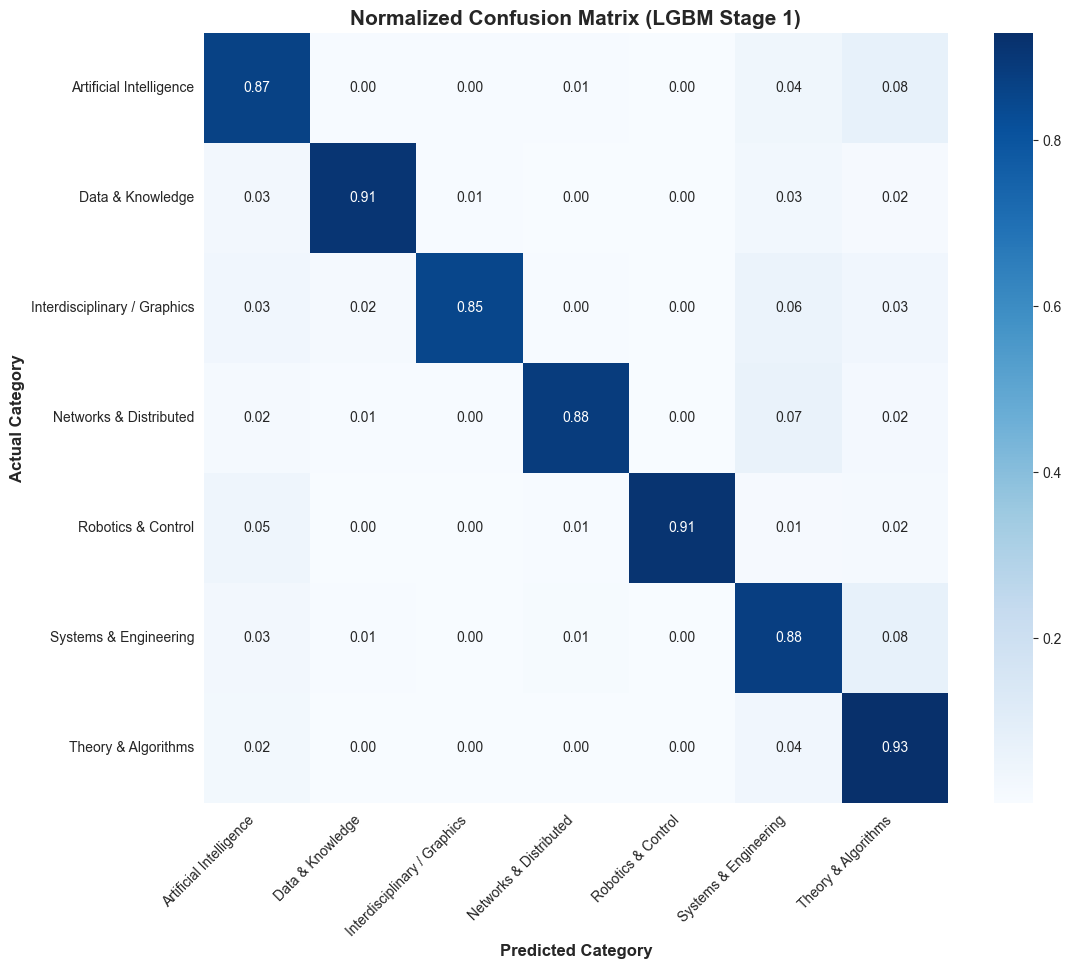


===== Confusion Matrix =====
[[2949   17   17   19    8  136  256]
 [  36 1196   10    5    5   43   20]
 [  22   12  544    3    1   36   22]
 [  18    6    5  953    1   72   22]
 [  28    1    2    5  568    8   10]
 [ 109   19   10   35    8 3236  278]
 [ 172   25   20   27   17  260 6767]]


In [16]:
# Evaluate Stage 1 Alone
_, cm = evaluate_classifier(clf_super, X_test, y_super_test)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12,10))
class_names = sorted(classification_df['super_label'].unique())
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt = '.2f',
    cmap='Blues',
    xticklabels = class_names,
    yticklabels = class_names,
)
plt.ylabel('Actual Category', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=12, fontweight='bold')
plt.title('Normalized Confusion Matrix (LGBM Stage 1)', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.savefig(f"{FIGURE_SAVE_PATH}/classification_stage1_confusion_matrix.png")
plt.show()
print("\n===== Confusion Matrix =====")

print(cm)

Stage 2 models:
- one classifier per super category we do 5-fold CV to evaluate each models performance.

- We don't do this for Stage 1 because Stage 1 only has 6-8 super categories, and SVM is best for crisp partitioning at that level.

- Stage 2 on the other hand has 32 final topics and is where the model choice matters.


In [17]:

models = {
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=SAMPLE_SEED),
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        multi_class="multinomial",
        class_weight="balanced"
    ),
    "Complement NB": ComplementNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "LightGBM": lgb.LGBMClassifier(
        num_leaves=64,
        n_estimators=300,
        learning_rate=0.05
    )
}
results = []

unique_supers = np.unique(y_super_train)

for sup in unique_supers:
    print(f"\n=== Evaluating Stage 2 models for super-category: {sup} ===")
    # indices belonging to this super category
    idx = np.where(y_super_train == sup)[0]
    X_train_sup = X_train[idx]
    y_topic_train_sup = y_topic_train[idx]

    for name, model in models.items():
        print(f"\n===== {name} =====")
        scoring = {
            "macro_f1": "f1_macro",
            "weighted_f1": "f1_weighted",
            "accuracy": "accuracy",
        }

        start = time.time()
        cv = cross_validate(
            model, X_train_sup, y_topic_train_sup,
            cv = 5,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )
        end = time.time()

        results.append({
            "Super-Category": sup,
            "Model": name,
            "Macro F1": np.mean(cv["test_macro_f1"]),
            "Weighted F1": np.mean(cv["test_weighted_f1"]),
            "Accuracy": np.mean(cv["test_accuracy"]),
            "Train Time (s)": end - start
        })

results_df = pd.DataFrame(results)
results_df


=== Evaluating Stage 2 models for super-category: Artificial Intelligence ===

===== Linear SVM =====

===== Logistic Regression =====

===== Complement NB =====

===== Random Forest =====

===== LightGBM =====

=== Evaluating Stage 2 models for super-category: Data & Knowledge ===

===== Linear SVM =====

===== Logistic Regression =====

===== Complement NB =====

===== Random Forest =====

===== LightGBM =====

=== Evaluating Stage 2 models for super-category: Interdisciplinary / Graphics ===

===== Linear SVM =====

===== Logistic Regression =====

===== Complement NB =====

===== Random Forest =====

===== LightGBM =====

=== Evaluating Stage 2 models for super-category: Networks & Distributed ===

===== Linear SVM =====

===== Logistic Regression =====

===== Complement NB =====

===== Random Forest =====

===== LightGBM =====

=== Evaluating Stage 2 models for super-category: Robotics & Control ===

===== Linear SVM =====

===== Logistic Regression =====

===== Complement NB ===

,Super-Category,Model,Macro F1,Weighted F1,Accuracy,Train Time (s)
0,Artificial Intelligence,Linear SVM,0.966451,0.965258,0.965236,9.922772
1,Artificial Intelligence,Logistic Regression,0.974781,0.973268,0.973247,1.841985
2,Artificial Intelligence,Complement NB,0.863476,0.845174,0.846539,1.522656
3,Artificial Intelligence,Random Forest,0.951349,0.951357,0.951271,15.272251
4,Artificial Intelligence,LightGBM,0.964910,0.963646,0.963692,115.891395
5,Data & Knowledge,Linear SVM,0.975610,0.984636,0.984594,0.159295
6,Data & Knowledge,Logistic Regression,0.964812,0.979933,0.979459,0.264977
7,Data & Knowledge,Complement NB,0.882974,0.903531,0.903956,0.151646
8,Data & Knowledge,Random Forest,0.962841,0.972556,0.972613,4.079323
9,Data & Knowledge,LightGBM,0.972591,0.980198,0.980220,22.240997


The metric scores of the above model are quite high but this is expected because Stage 2 CV:
- assumes we already know the correct super category
- It never sees Stage-1 Mistakes
- never evaluates across irrelevant classes ie (CV inside AI doesn't need to consider Theory Topics)

In order to get the final accuracy of the model we do
$$
\text{Final Accuracy} = \text{P(Stage-1 correct)} \times \text{P(Stage-2 correct | Stage-1 correct)}
$$

In [20]:
results_df.to_csv(f"{TABLE_SAVE_PATH}/classification_stage2_5cv.csv")

In [26]:
results_df = pd.read_csv(f"{TABLE_SAVE_PATH}/classification_stage2_5cv.csv")

print(results_df.groupby('Model')[['Macro F1', 'Weighted F1', 'Accuracy', 'Train Time (s)']].agg('mean').round(2))

                     Macro F1  Weighted F1  Accuracy  Train Time (s)
Model                                                               
Complement NB            0.85         0.88      0.89            0.33
LightGBM                 0.96         0.97      0.97           89.37
Linear SVM               0.95         0.97      0.97            1.74
Logistic Regression      0.95         0.97      0.97            0.62
Random Forest            0.94         0.95      0.96           12.59


Since Stage-2 is responsible for distinguishing fine-grained subtopics within each category the ideal Stage 2-model should have

- High Macro F1
- Good weighted F1 / accuracy
- Good Runtime

Based on the DF above we go ahead and choose LightGBM despite the lower runtime


Hierarchical Prediction Function (Stage 1 -> Stage 2)

In [ ]:
stage2_models = {}

unique_supers = np.unique(y_super_train)
for sup in unique_supers:
    idx = np.where(y_super_train == sup)[0]
    X_train_sup = X_train[idx]
    y_topic_train_sup = y_topic_train[idx]

    clf = lgb.LGBMClassifier(
        num_leaves=64,
        n_estimators=300,
        learning_rate=0.05,
        random_state=SAMPLE_SEED
    )
    clf.fit(X_train_sup, y_topic_train_sup)
    stage2_models[sup] = clf

    print(f"Trained Stage 2 model for {sup} "
          f"on {X_train_sup.shape[0]} samples "
          f"and {len(np.unique(y_topic_train_sup))} topics.")


def hierarchical_predict(X, clf_super, stage2_models):
    """
    X: feature matrix
    returns:
        y_topic_pred: final fine-grained topic predictions
        y_super_pred: intermediate super-category predictions
    """
    # predict super categories
    y_super_pred = clf_super.predict(X)

    # Prepare container
    y_topic_pred = np.empty_like(y_super_pred, dtype=object)

    # For each super category, route to its Stage 2 model
    for sup in np.unique(y_super_pred):
        idx = np.where(y_super_pred == sup)[0]
        X_sup = X[idx]
        clf_stage2 = stage2_models[sup]
        y_topic_pred[idx] = clf_stage2.predict(X_sup)

    return y_topic_pred, y_super_pred

y_topic_pred, y_super_pred = hierarchical_predict(
    X_test,
    clf_super,
    stage2_models
)

Evaluate Hierarchy Model Performance.

Note that we are doing LGBM ->  LGBM

Overall Hierarchical Accuracy: 0.8627
                                             precision    recall  f1-score   support

                  Algorithms & Optimization       0.86      0.90      0.88      2909
                Computer Science & Graphics       0.91      0.91      0.91       407
                            Computer Vision       0.94      0.93      0.93       685
                 Control Systems & Robotics       0.95      0.93      0.94       496
                 Databases & Knowledge Mgmt       0.94      0.88      0.91       607
      Decision Support & Business Processes       0.73      0.74      0.74       692
Detection, Structure & Object/Video Methods       0.75      0.71      0.73      1465
       Discrete-Event Simulation & Modeling       0.76      0.87      0.81       157
        Distributed Systems & Communication       0.76      0.82      0.79        95
             Extended Abstracts & Protocols       0.90      0.75      0.82        36
                          

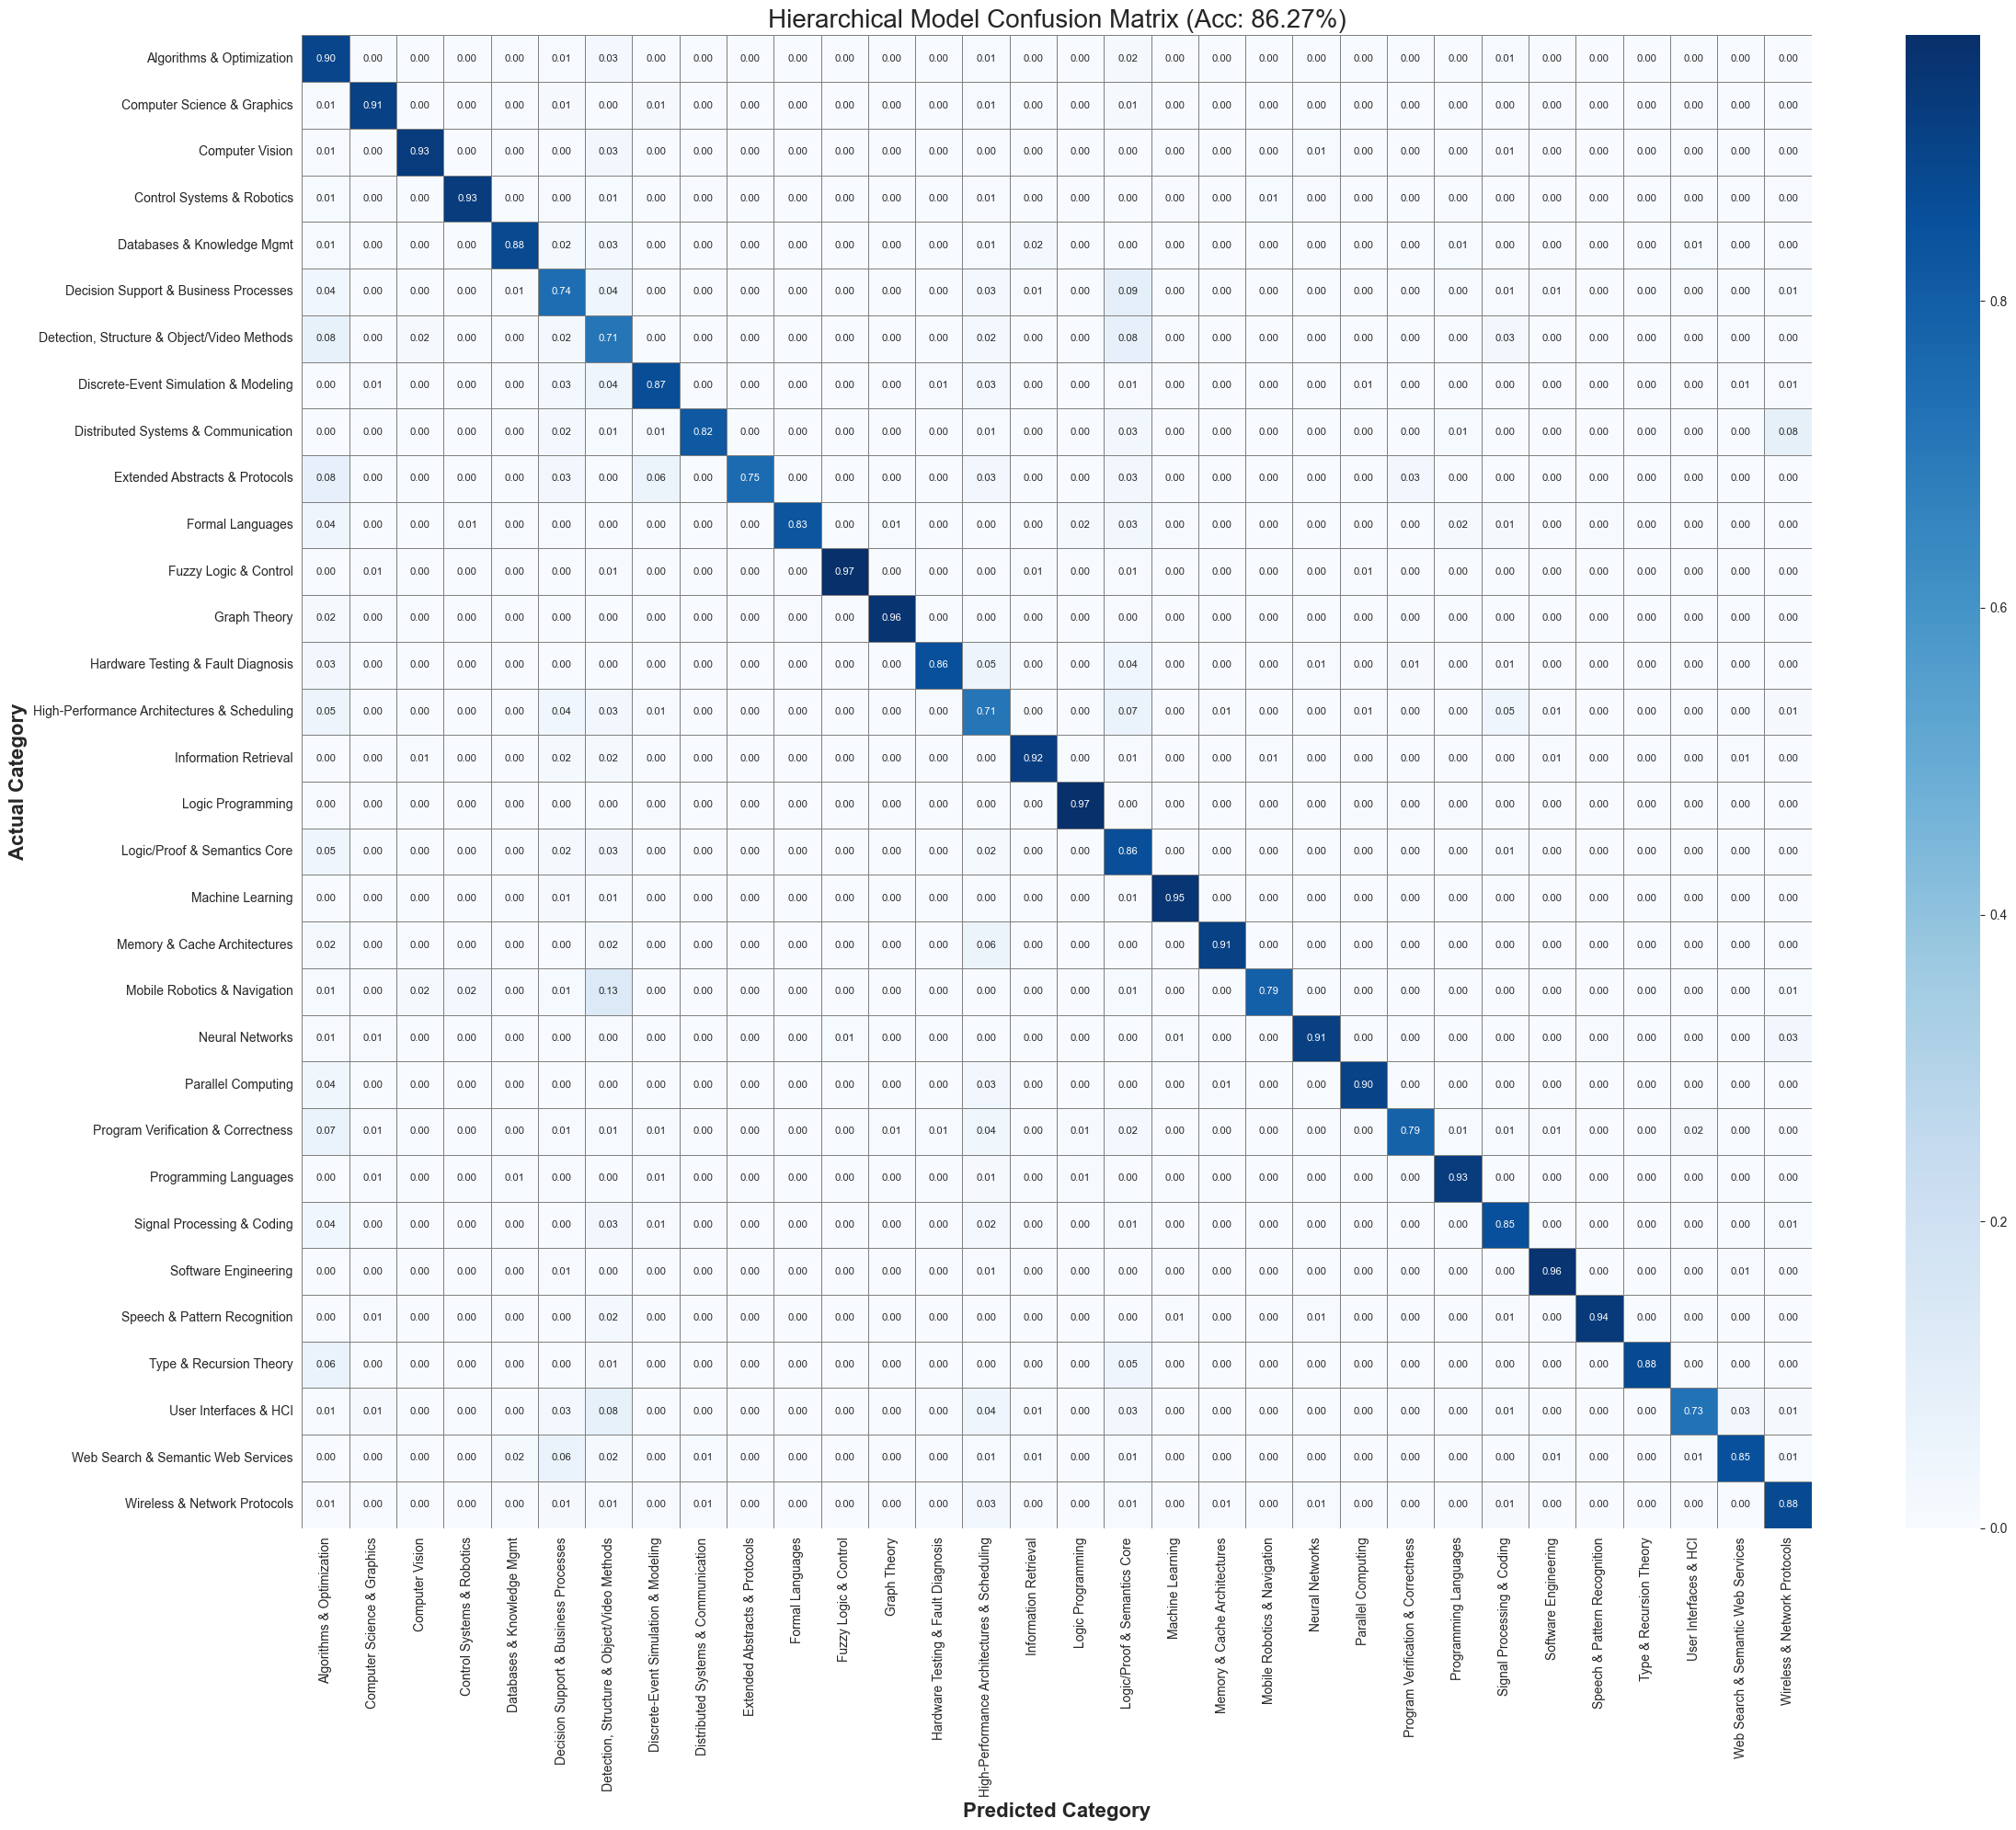

===== Confusion Matrix Hierarchical Model ======
[[2605    3    3 ...    1    1    9]
 [   3  370    1 ...    2    0    0]
 [   4    1  637 ...    2    0    0]
 ...
 [   2    3    0 ...  169    7    3]
 [   0    0    0 ...    1  112    1]
 [   5    2    1 ...    3    3  860]]


In [27]:
overall_accuracy = accuracy_score(y_topic_test, y_topic_pred)
print(f"Overall Hierarchical Accuracy: {overall_accuracy:.4f}")
print(classification_report(y_topic_test, y_topic_pred))
cm = confusion_matrix(y_topic_test, y_topic_pred, labels=np.unique(y_topic_test))
print("\n===== Confusion Matrix =====")
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
class_names = sorted(np.unique(y_topic_test))

plt.figure(figsize=(24, 20))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor='gray'
)

plt.ylabel('Actual Category', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=16, fontweight='bold')
plt.title(f'Hierarchical Model Confusion Matrix (Acc: {overall_accuracy:.2%})', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/classification_stage2_confusion_matrix.png")
plt.show()

print("===== Confusion Matrix Hierarchical Model ======")
print(cm)

The figures and tables are way too big to include in our report so we only show top and bottom 5

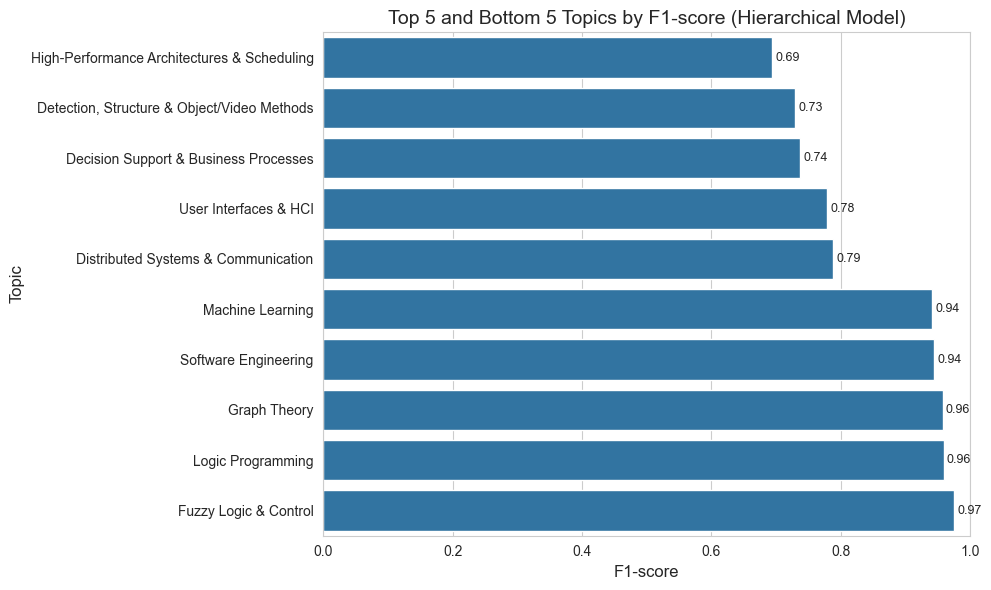

In [29]:
report_dict = classification_report(y_topic_test, y_topic_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df = report_df[~report_df.index.isin(["accuracy", "macro avg", "weighted avg"])]
report_df_sorted = report_df.sort_values("f1-score")
bottom5 = report_df_sorted.head(5)
top5 = report_df_sorted.tail(5)
top_bottom = pd.concat([bottom5, top5])
top_bottom = top_bottom[~top_bottom.index.duplicated(keep="first")]
top_bottom["Topic"] = top_bottom.index
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_bottom,
    x="f1-score",
    y="Topic",
)
plt.xlabel("F1-score", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.title("Top 5 and Bottom 5 Topics by F1-score (Hierarchical Model)", fontsize=14)
for i, (f1, topic) in enumerate(zip(top_bottom["f1-score"], top_bottom["Topic"])):
    plt.text(f1 + 0.005, i, f"{f1:.2f}", va="center", fontsize=9)

plt.xlim(0, 1.0)
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/classification_top_bottom10_f1.png", dpi=300)
plt.show()

# Task 5: Network Analysis

Libraries for this section

In [1]:
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import ast

plt.style.use("seaborn-v0_8")

Centrality Measures to identify key authors

In [21]:
papers = sampled_df.dropna(subset=["id"]).copy()

# Ensure types
papers["id"] = papers["id"].astype(str)
papers['year'] = papers['year'].dt.year
papers['year'] = papers['year'].astype(int)

# Build Lookup
valid_ids = set(papers["id"].tolist())

# Robust Reference Parser (The Fix)
def parse_references(refs):
    # Check if it's already a list or array BEFORE checking isna
    if isinstance(refs, (list, np.ndarray)):
        return refs

    # Check for empty/nan
    if pd.isna(refs) or refs == "":
        return []

    # Check for string representation
    if isinstance(refs, str):
        refs = refs.strip()
        if refs.startswith("["):
            try:
                # ast.literal_eval is safer than eval
                return ast.literal_eval(refs)
            except:
                return []
    return []

# Build Graph
G = nx.DiGraph()

# Add Nodes
for _, row in papers.iterrows():
    G.add_node(
        str(row["id"]),
        year=row["year"],
        title=row.get("title", "Untitled"),
        n_citation=row.get("n_citation", 0)
    )

# Add Edges
for _, row in papers.iterrows():
    src_id = str(row["id"])
    ref_ids = parse_references(row["references"])

    for tgt_id in ref_ids:
        tgt_id = str(tgt_id)
        # ONLY add edge if the target is also in our sample (valid_ids)
        if tgt_id in valid_ids and tgt_id != src_id:
            G.add_edge(src_id, tgt_id)

# Output Stats for Report
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

Nodes: 90191
Edges: 105526


Compute PageRank (influence)

In [22]:
# Compute PageRank scores
pagerank_scores = nx.pagerank(G, alpha=0.85)

# Convert to DataFrame for easier inspection
pr_df = (
    pd.DataFrame.from_dict(pagerank_scores, orient="index", columns=["pagerank"])
    .reset_index()
    .rename(columns={"index": "id"})
)

# Join with metadata for context
pr_df = pr_df.merge(
    papers[["id", "title", "year", "n_citation", "topic_label", "super_topic"]],
    on="id",
    how="left"
)

# Sort by PageRank
top_pr = pr_df.sort_values("pagerank", ascending=False).head(10)

top_pr


,id,pagerank,title,year,n_citation,topic_label,super_topic
3376,e930195e-baa4-4d42-9d5f-e042fcaf5a9e,0.003009,a relational model of data for large shared da...,1970,7295,Information Retrieval,Data & Knowledge
370,b0f6455a-6f99-42c5-8502-4fa535768ceb,0.002666,finite automata and their decision problems,1959,1904,Algorithms & Optimization,Theory & Algorithms
362,30d6974a-89c0-45c6-b7d1-31385ce46166,0.002162,computability and unsolvability.,1959,896,Logic/Proof & Semantics Core,Theory & Algorithms
408,1cecb6af-a150-4abe-a950-6ceab75d015f,0.001904,the reduction of two-way automata to one-way a...,1959,299,Logic/Proof & Semantics Core,Theory & Algorithms
4165,8d09527f-b5ad-4902-ba34-5583f6759d3b,0.001491,the complexity of theorem-proving procedures,1971,7314,Algorithms & Optimization,Theory & Algorithms
12369,3fb43b00-905c-4a08-934d-198ea4eb66c3,0.001489,a method for obtaining digital signatures and ...,1978,18861,Logic/Proof & Semantics Core,Theory & Algorithms
1639,112eeff7-c265-4808-aef5-55f592540e40,0.001482,a machine-oriented logic based on the resoluti...,1965,4013,Logic Programming,Theory & Algorithms
9713,ca394e6a-59e0-466c-a66a-d976555db689,0.001467,new directions in cryptography,1976,17064,Algorithms & Optimization,Theory & Algorithms
532,c0a69970-4b14-492a-adcc-6928988a9f2a,0.001394,a computing procedure for quantification theory,1960,2535,Algorithms & Optimization,Theory & Algorithms
3269,1f016091-9509-4fee-b43b-85552aac7064,0.001393,an algol-based associative language,1969,229,Programming Languages,Theory & Algorithms


Degree & betweeness centrality

In [23]:
# In-degree and out-degree
in_degrees = dict(G.in_degree())   # citations received inside sample
out_degrees = dict(G.out_degree()) # references made inside sample

deg_df = pd.DataFrame({
    "id": list(in_degrees.keys()),
    "in_degree": list(in_degrees.values()),
    "out_degree": [out_degrees[n] for n in in_degrees.keys()],
})

# Merge with metadata
deg_df = deg_df.merge(
    papers[["id", "title", "year", "topic_label", "super_topic"]],
    on="id",
    how="left"
)

# Top 10 by in-degree (most-cited in-sample)
top_in_degree = deg_df.sort_values("in_degree", ascending=False).head(10)

# Top 10 by out-degree (heavy referencing, likely surveys/reviews)
top_out_degree = deg_df.sort_values("out_degree", ascending=False).head(10)

top_in_degree, top_out_degree


(                                         id  in_degree  out_degree  \
 3376   e930195e-baa4-4d42-9d5f-e042fcaf5a9e        401           2   
 4165   8d09527f-b5ad-4902-ba34-5583f6759d3b        239           3   
 2839   35c8c06c-2ad0-46b4-9e92-2d684f3abd94        207           1   
 12369  3fb43b00-905c-4a08-934d-198ea4eb66c3        204           4   
 1639   112eeff7-c265-4808-aef5-55f592540e40        203           2   
 12655  136c4780-2f25-4068-90a5-aed6afaf2890        195           0   
 8467   35b671b4-5e95-4a09-bae3-f0d94e648119        184           1   
 9713   ca394e6a-59e0-466c-a66a-d976555db689        170           4   
 26855  510eec1d-f82c-4b19-b116-b8fd4c66531a        155           0   
 370    b0f6455a-6f99-42c5-8502-4fa535768ceb        135           1   
 
                                                    title  year  \
 3376   a relational model of data for large shared da...  1970   
 4165        the complexity of theorem-proving procedures  1971   
 2839         an

Betweeenness (approximate)

In [24]:
# Approximate betweenness centrality:
# k is the number of nodes used for approximation (tune depending on size)
num_nodes = G.number_of_nodes()
k_sample = min(200, max(30, num_nodes // 100))  # heuristic

betw_scores = nx.betweenness_centrality(G, k=k_sample, seed=42)

betw_df = (
    pd.DataFrame.from_dict(betw_scores, orient="index", columns=["betweenness"])
    .reset_index()
    .rename(columns={"index": "id"})
)

betw_df = betw_df.merge(
    papers[["id", "title", "year", "topic_label", "super_topic"]],
    on="id",
    how="left"
)

top_betw = betw_df.sort_values("betweenness", ascending=False).head(10)
top_betw


,id,betweenness,title,year,topic_label,super_topic
31909,fb63d6ff-e212-4ebb-8865-c8f57da45adf,0.000094,optimization of large join queries,1988,Algorithms & Optimization,Theory & Algorithms
2827,f42afb96-05f2-4d2b-932f-180a8ba9f47e,0.000084,translator writing systems,1968,Logic/Proof & Semantics Core,Theory & Algorithms
48396,e71780ab-13be-417d-9968-7834368c78fd,0.000084,walking away from the desktop computer: distri...,1996,Computer Science & Graphics,Interdisciplinary / Graphics
24594,f0926b94-87ac-4fb7-8086-9143bdc10fe9,0.000075,query optimization in database systems,1984,Databases & Knowledge Mgmt,Data & Knowledge
51875,daa6f698-4df7-4054-bd87-75616d68acc0,0.000069,a metaobject architecture for fault-tolerant d...,1998,Databases & Knowledge Mgmt,Data & Knowledge
2683,507f5bb5-796f-4eac-a447-224dcbbae973,0.000068,curriculum 68: recommendations for academic pr...,1968,Computer Science & Graphics,Interdisciplinary / Graphics
16702,476da5ad-45c8-4bd9-b359-804af6ef1aec,0.000063,variations on the common subexpression problem,1980,Logic/Proof & Semantics Core,Theory & Algorithms
25628,d228b01a-16e5-4164-af30-05d3f1bb270b,0.000060,a time bound on the materialization of some re...,1985,Algorithms & Optimization,Theory & Algorithms
3106,9d141acb-2179-4046-9546-892a353946ff,0.000059,toward a theory of enumerations,1969,Algorithms & Optimization,Theory & Algorithms
28901,77885af1-2abe-42b3-9f35-8a8e88e2c1d6,0.000056,semistructured messages are surprisingly usefu...,1987,Computer Science & Graphics,Interdisciplinary / Graphics


Ego Graph visualization

Top PageRank paper:
a relational model of data for large shared data banks - e930195e-baa4-4d42-9d5f-e042fcaf5a9e
Ego graph nodes: 3, edges: 3


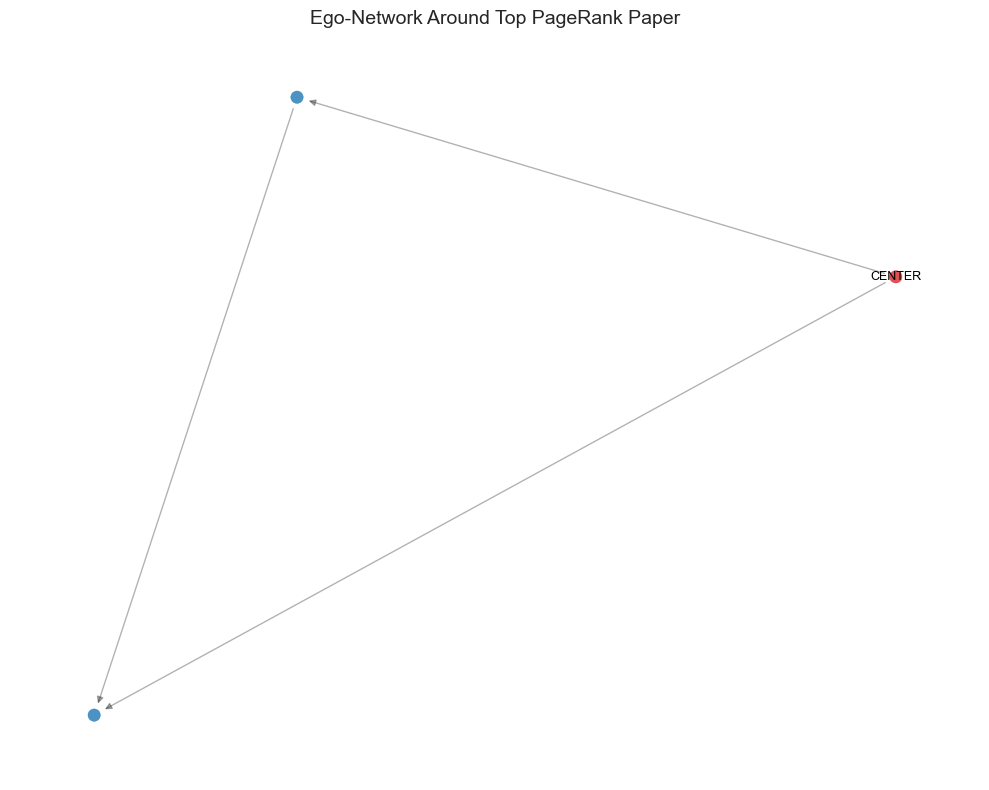

In [25]:
import matplotlib.pyplot as plt

# Pick the most influential paper by PageRank
top_node = top_pr.iloc[0]["id"]
top_title = top_pr.iloc[0]["title"]

print("Top PageRank paper:")
print(top_title, "-", top_node)

# Ego graph: 1-hop neighborhood
radius = 1  # neighbors directly citing or cited by this node
ego = nx.ego_graph(G, top_node, radius=radius, undirected=False)

print(f"Ego graph nodes: {ego.number_of_nodes()}, edges: {ego.number_of_edges()}")

# Layout
pos = nx.spring_layout(ego, k=0.4, iterations=100, seed=42)

# Node colors: center vs neighbors
node_colors = []
for n in ego.nodes():
    if n == top_node:
        node_colors.append("tab:red")
    else:
        node_colors.append("tab:blue")

plt.figure(figsize=(10, 8))

# Draw nodes
nx.draw_networkx_nodes(
    ego,
    pos,
    node_size=80,
    node_color=node_colors,
    alpha=0.8
)

# Draw edges
nx.draw_networkx_edges(
    ego,
    pos,
    arrowstyle="-|>",
    arrowsize=10,
    alpha=0.3
)

# Optionally label only the center node or a few neighbors
labels = {top_node: "CENTER"}
nx.draw_networkx_labels(ego, pos, labels=labels, font_size=9)

plt.title("Ego-Network Around Top PageRank Paper", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig(f"{FIGURE_SAVE_PATH}/citation_network_ego_top_pagerank.png", dpi=300)
plt.show()


In [26]:
# Top papers by different centrality metrics

top_pr_short = top_pr[["id", "title", "year", "topic_label", "pagerank"]].copy()
top_pr_short["metric"] = "PageRank"

top_in_short = top_in_degree[["id", "title", "year", "topic_label", "in_degree"]].copy()
top_in_short = top_in_short.rename(columns={"in_degree": "score"})
top_in_short["metric"] = "in_degree"

top_betw_short = top_betw[["id", "title", "year", "topic_label", "betweenness"]].copy()
top_betw_short = top_betw_short.rename(columns={"betweenness": "score"})
top_betw_short["metric"] = "betweenness"

top_pr_short = top_pr_short.rename(columns={"pagerank": "score"})

summary_centrality = pd.concat([top_pr_short, top_in_short, top_betw_short], ignore_index=True)

summary_centrality.head(15)


,id,title,year,topic_label,score,metric
0,e930195e-baa4-4d42-9d5f-e042fcaf5a9e,a relational model of data for large shared da...,1970,Information Retrieval,0.003009,PageRank
1,b0f6455a-6f99-42c5-8502-4fa535768ceb,finite automata and their decision problems,1959,Algorithms & Optimization,0.002666,PageRank
2,30d6974a-89c0-45c6-b7d1-31385ce46166,computability and unsolvability.,1959,Logic/Proof & Semantics Core,0.002162,PageRank
3,1cecb6af-a150-4abe-a950-6ceab75d015f,the reduction of two-way automata to one-way a...,1959,Logic/Proof & Semantics Core,0.001904,PageRank
4,8d09527f-b5ad-4902-ba34-5583f6759d3b,the complexity of theorem-proving procedures,1971,Algorithms & Optimization,0.001491,PageRank
5,3fb43b00-905c-4a08-934d-198ea4eb66c3,a method for obtaining digital signatures and ...,1978,Logic/Proof & Semantics Core,0.001489,PageRank
6,112eeff7-c265-4808-aef5-55f592540e40,a machine-oriented logic based on the resoluti...,1965,Logic Programming,0.001482,PageRank
7,ca394e6a-59e0-466c-a66a-d976555db689,new directions in cryptography,1976,Algorithms & Optimization,0.001467,PageRank
8,c0a69970-4b14-492a-adcc-6928988a9f2a,a computing procedure for quantification theory,1960,Algorithms & Optimization,0.001394,PageRank
9,1f016091-9509-4fee-b43b-85552aac7064,an algol-based associative language,1969,Programming Languages,0.001393,PageRank
